# 03 — Reading a reported number back to the case report form

The CDISC SDTM/ADaM Pilot Project is a complete, public, fictional submission: annotated
CRF, SDTM tabulations, ADaM analysis datasets, `define.xml` at both levels, and a 492-page
study report with the actual tables. Every link between a collected value and a printed
number is present, which is what makes the walk-back below possible from outside a sponsor.

Those analysis datasets were built to answer one pre-specified question. Which subjects
count, which record of a repeated measurement counts, what happens when someone stops
turning up, what a visit label means: all decided in advance, all written down, none of it
carried by the table itself.

This notebook rebuilds the study's **primary endpoint**, ADAS-Cog (11) change from baseline
to Week 24, dose-response **p = 0.245** from Table 14-3.01. Agreement is what confirms those
decisions have been read as intended. The later sections then sort the 88 columns by what
each one can be used for.

### What this notebook does

Six passes over the same package, each one checking the last:

1. **Find the number.** Read Table 14-3.01 out of the report, then read what `define.xml`
   says about how it was produced.
2. **Run the documentation.** Execute every row filter the metadata declares, literally as
   written, and count what comes back.
3. **Rebuild the result.** Compare against the printed table and against the raw SAS output
   the report carries near the back.
4. **Push it further.** The same model at the other two visits, and the repeated-measures
   analysis, checked the same way.
5. **Walk down to the form.** Follow one row's pointer into SDTM and on toward the CRF, and
   find where the trail stops.
6. **Sort the columns.** Technical, result and feature, then reshape into one row per
   subject.

It needs `./setup.sh` to have run. Every number printed against a "report" or "SAS" value is
a real comparison, and where something does not match the cell says so rather than hiding it.

Runs in about ten seconds.

## The inputs

`setup.sh` fetches thirteen files pinned to one commit. The ADaM and SDTM datasets ship as
both SAS transport and Dataset-JSON; the JSON needs no special reader, so that is what this
uses.

In [1]:
# Load the thirteen downloaded files and the plotting style. Nothing is computed here.
import json, re, itertools
import xml.etree.ElementTree as ET
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pypdf
from patsy import dmatrix
from scipy import stats
from matplotlib.patches import FancyBboxPatch

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8a8880", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "font.family": "sans-serif",
    "font.size": 11, "text.color": INK, "figure.dpi": 160,
})


DATA = Path("data")
EXPECTED = [
    "adam/adsl.json", "adam/adae.json", "adam/adlbc.json", "adam/adlbh.json",
    "adam/adlbhy.json", "adam/adqsadas.json", "adam/adqscibc.json",
    "adam/adqsnpix.json", "adam/adtte.json", "adam/define.xml",
    "sdtm/qs.json", "sdtm/define.xml", "csr/cdiscpilot01.pdf",
]
missing = [f for f in EXPECTED if not (DATA / f).exists()]
if missing:
    raise SystemExit(f"missing {len(missing)} input file(s), run ./setup.sh first: {missing}")
print(f"all {len(EXPECTED)} input files present")


def read_dataset_json(path):
    """Dataset-JSON v1.1 -> DataFrame, with column labels kept on .attrs."""
    d = json.loads(Path(path).read_text())
    cols = [c["name"] for c in d["columns"]]
    df = pd.DataFrame(d["rows"], columns=cols)
    df.attrs["labels"] = {c["name"]: c.get("label", "") for c in d["columns"]}
    df.attrs["label"] = d.get("label", "")
    return df


def adam(name):
    return read_dataset_json(DATA / "adam" / f"{name.lower()}.json")


ADAS = adam("ADQSADAS")
print(f"ADQSADAS: {ADAS.shape[0]:,} rows x {ADAS.shape[1]} columns — {ADAS.attrs['label']}")

all 13 input files present
ADQSADAS: 12,463 rows x 40 columns — ADAS-Cog Analysis


## How the package is put together

Before chasing any number, the shape of the thing. Each layer below is derived from the one
above it, and `define.xml` describes all of them.

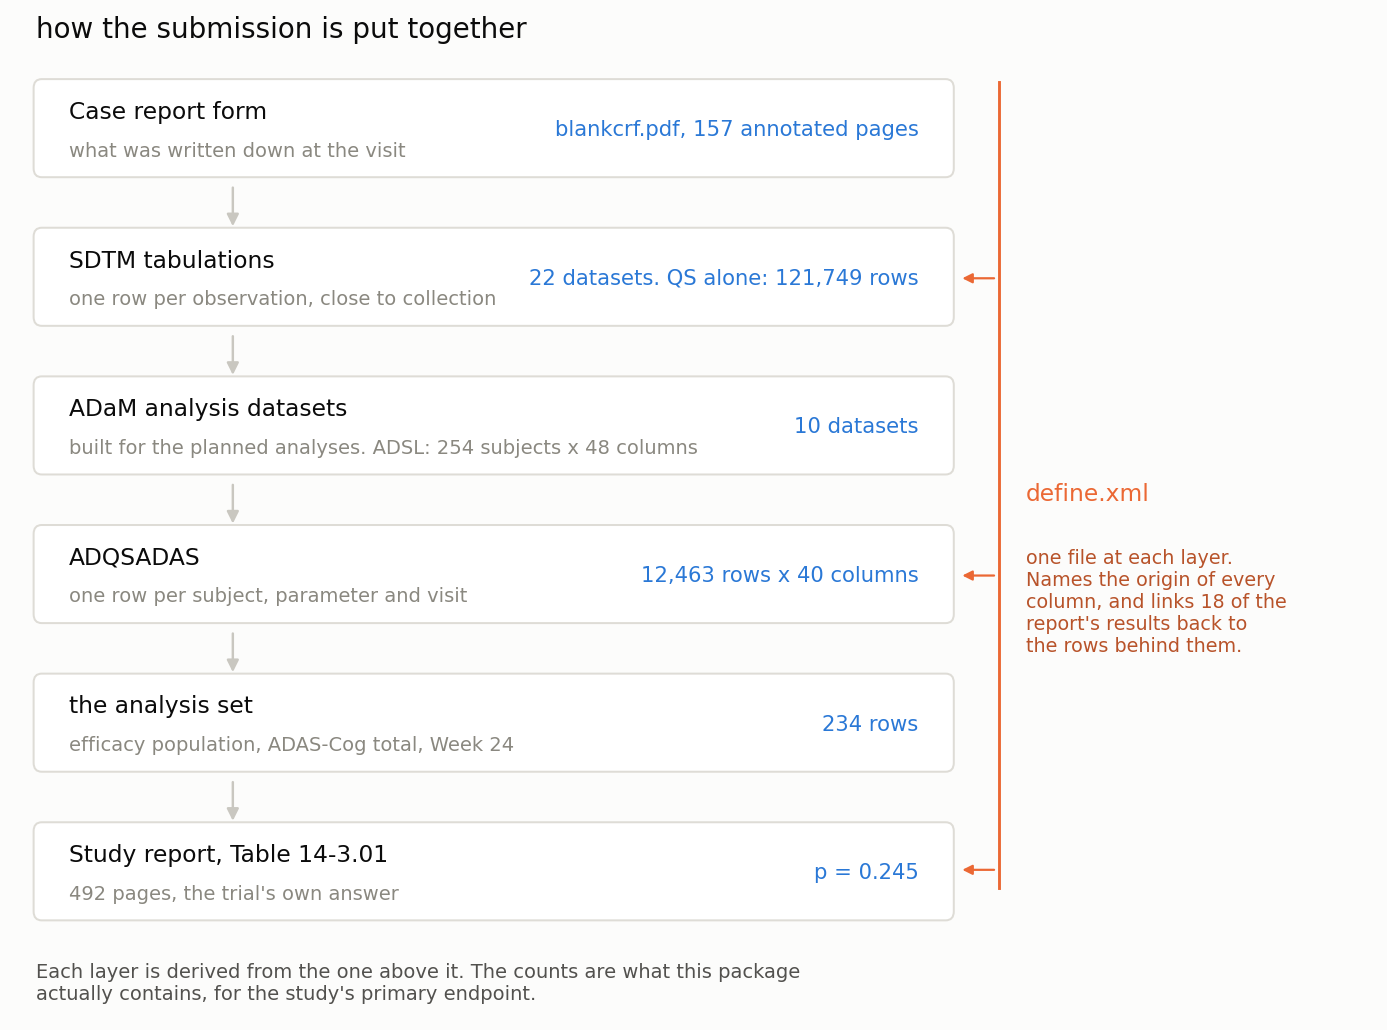

In [2]:
# Presentation only. How the package is laid out, and how many rows survive each step
# from the case report form to the number the report prints.
LAYERS = [
    ("Case report form",        "blankcrf.pdf, 157 annotated pages",
     "what was written down at the visit"),
    ("SDTM tabulations",        "22 datasets. QS alone: 121,749 rows",
     "one row per observation, close to collection"),
    ("ADaM analysis datasets",  "10 datasets",
     "built for the planned analyses. ADSL: 254 subjects x 48 columns"),
    ("ADQSADAS",                "12,463 rows x 40 columns",
     "one row per subject, parameter and visit"),
    ("the analysis set",        "234 rows",
     "efficacy population, ADAS-Cog total, Week 24"),
    ("Study report, Table 14-3.01", "p = 0.245",
     "492 pages, the trial's own answer"),
]

n = len(LAYERS)
fig, ax = plt.subplots(figsize=(8.8, 6.6))
ax.set_xlim(0, 10); ax.set_ylim(-0.55, n + 0.15); ax.axis("off")
BOX_L, BOX_R = 0.15, 6.9

for i, (head, count, note) in enumerate(LAYERS):
    y = n - 1 - i
    ax.add_patch(FancyBboxPatch(
        (BOX_L, y + 0.10), BOX_R - BOX_L, 0.62,
        boxstyle="round,pad=0.02,rounding_size=0.06",
        linewidth=0.9, edgecolor="#dedcd6", facecolor="#ffffff"))
    ax.text(BOX_L + 0.24, y + 0.52, head, fontsize=10.5, color=INK, va="center")
    ax.text(BOX_L + 0.24, y + 0.26, note, fontsize=8.8, color=MUTED, va="center")
    ax.text(BOX_R - 0.24, y + 0.40, count, fontsize=9.5, color=BLUE,
            va="center", ha="right")
    if i < n - 1:
        ax.annotate("", xy=(1.6, y - 0.28), xytext=(1.6, y + 0.04),
                    arrowprops=dict(arrowstyle="-|>", color="#c9c7c0",
                                    linewidth=1.1, mutation_scale=11))

# define.xml runs alongside the whole stack rather than sitting inside it
ax.plot([7.25, 7.25], [0.30, n - 0.28], color=ORANGE, linewidth=1.3)
for y in (n - 1.6, n - 3.6, 0.42):
    ax.annotate("", xy=(6.95, y), xytext=(7.25, y),
                arrowprops=dict(arrowstyle="-|>", color=ORANGE,
                                linewidth=1.0, mutation_scale=9))
ax.text(7.45, (n - 0.4) / 2 + 0.15, "define.xml", fontsize=10.5, color=ORANGE,
        va="center", rotation=0)
ax.text(7.45, (n - 0.4) / 2 - 0.22,
        "one file at each layer.\nNames the origin of every\ncolumn, and links 18 of the\n"
        "report's results back to\nthe rows behind them.",
        fontsize=8.6, color="#b8532a", va="top")

ax.text(BOX_L, n - 0.02, "how the submission is put together",
        fontsize=12.5, color=INK, va="bottom")
ax.text(BOX_L, -0.34,
        "Each layer is derived from the one above it. The counts are what this package\n"
        "actually contains, for the study's primary endpoint.",
        fontsize=8.8, color=INK2, va="center")
fig.tight_layout()
fig.savefig(FIG / "00-how-it-connects.png", bbox_inches="tight")

## The number

Table 14-3.01, lifted out of the study report PDF rather than typed in here, so that what
follows is compared against the document itself.

In [3]:
# Pull Table 14-3.01 out of the 492-page report PDF, so the target number is read from
# the document rather than typed in.
csr = pypdf.PdfReader(DATA / "csr" / "cdiscpilot01.pdf")
page = next(p for p in csr.pages
            if "Table 14-3.01" in (p.extract_text() or "")
            and "p-value(Dose Response)" in (p.extract_text() or ""))
report = page.extract_text()
print(f"{len(csr.pages)} pages in the study report; this is the one that carries "
      f"the primary endpoint\n")
print(report.strip())

492 pages in the study report; this is the one that carries the primary endpoint

Protocol: CDISCPILOT01                                                                  Page  1 of 1 
Population: Efficacy 
Table 14-3.01 
Primary Endpoint Analysis: ADAS Cog (11) - Change from Baseline to Week 24 - LOCF 
 
 
[1] Based on Analysis of covariance (ANCOVA) model with treatment and site group as factors and baseline 
value as a covariate. 
[2] Test for a non-zero coefficient for treatment (dose) as a continuous variable. [3] Pairwise comparison with treatment as a categorical variable: p-values without adjustment for multiple 
comparisons. 
Source: C:\cdisc_pilot\PROGRAMS\DRAFT\TFLs\rtf_eff1.sas                  21:05 Monday, June 26, 2006 
 
Placebo 
 (N=79)  
Xanomeline 
 Low Dose 
 (N=81)  
Xanomeline 
 High Dose 
 (N=74)  
Baseline 
  n                                   79   81   74 
  Mean (SD)                           24.1 (12.19)   24.4 (12.92)   21.3 (11.74) 
  Median (Range)        

## What the metadata says about the primary endpoint

Define-XML carries **Analysis Results Metadata**: for each display in the report, which
datasets fed it, which rows were selected, which variables were analysed, and the code that
produced it. This is the layer that makes the walk-back possible at all, without it there
is nothing linking a table in a PDF to a column in a dataset.

Here is the record for Table 14-3.01, both results.

In [4]:
# Parse the ADaM define.xml and print the analysis results metadata for the primary
# endpoint: which dataset, which rows, which variables, which code.
NS = re.compile(r"\{.*?\}")
def tag(e): return NS.sub("", e.tag)
def attr(e, name):
    for k, v in e.attrib.items():
        if NS.sub("", k) == name:
            return v
def text(e): return " ".join("".join(e.itertext()).split())

define_adam = ET.parse(DATA / "adam" / "define.xml").getroot()

def analysis_results(root):
    """Every AnalysisResults element, with the datasets and filters it declares."""
    out = []
    for ar in root.iter():
        if tag(ar) != "AnalysisResults":
            continue
        rec = {"oid": attr(ar, "OID"), "reason": attr(ar, "Reason"),
               "identifier": attr(ar, "ResultIdentifier"), "variables": [],
               "params": [], "datasets": [], "doc": None, "code": None, "code_leaf": None}
        for ch in ar:
            t = tag(ch)
            if t == "ParameterList":
                rec["params"] = [attr(p, "ParamCD") for p in ch if tag(p) == "Parameter"]
            elif t == "AnalysisVariable":
                rec["variables"].append(attr(ch, "ItemOID"))
            elif t == "AnalysisDataset":
                name, crit = None, None
                for x in ch.iter():
                    if tag(x) == "ItemGroupRef":
                        name = attr(x, "ItemGroupOID")
                    elif tag(x) == "SelectionCriteria":
                        crit = text(x)
                rec["datasets"].append((name, crit))
            elif t == "Documentation":
                rec["doc"] = text(ch) or None
            elif t == "ProgrammingCode":
                rec["code"] = text(ch) or None
                rec["code_leaf"] = attr(ch, "leafID")
        out.append(rec)
    return out


RESULTS = analysis_results(define_adam)
print(f"{len(RESULTS)} AnalysisResults in the ADaM define.xml\n")

primary = [r for r in RESULTS if r["oid"].startswith("Table_14-3.01")]
for r in primary:
    print("=" * 78)
    print(f"{r['oid']}  ({r['reason']})")
    print(f"  identifier : {r['identifier']}")
    print(f"  parameters : {r['params']}")
    print(f"  variables  : {r['variables']}")
    for name, crit in r["datasets"]:
        print(f"  dataset    : {name}")
        print(f"  filter     : {crit}")
    print(f"  code       : {r['code']}")

18 AnalysisResults in the ADaM define.xml

Table_14-3.01.R.1  (Primary Endpoint Analysis; pre-specified in SAP)
  identifier : dose response analysis for ADAS-Cog changes from baseline
  parameters : ['ACTOT']
  variables  : ['ADQSADAS.CHG']
  dataset    : ADQSADAS
  filter     : [ EFFFL="Y" and ANL01FL="Y" and AVISIT="Week 24" and PARAMCD="ATOT" ]
  code       : proc glm data = ADQSADAS; where EFFFL='Y' and ANL01FL='Y' and AVISIT='Week 24' and PARAMCD="ATOT"; class sitegr1; model CHG = trtpn sitegr1; run;
Table_14-3.01.R.2  (Primary Endpoint Analysis; pre-specified in SAP)
  identifier : pairwise comparisons to placebo for ADAS-Cog changes from baseline
  parameters : ['ACTOT']
  variables  : ['ADQSADAS.CHG']
  dataset    : ADQSADAS
  filter     : [ EFFFL="Y" and ANL01FL="Y" and AVISIT="Week 24" and PARAMCD="ATOT" ]
  code       : proc glm data = ADQSADAS; where EFFFL='Y' and ANL01FL='Y' and AVISIT='Week 24' and PARAMCD="ATOT"; class trtpn sitegr1; model CHG = trtpn sitegr1 base; mean

## Running every documented filter

The selection criteria are written in a small expression language. They are meant for a
human reader, but they are regular enough to execute. So execute all of them, literally as
written, against the datasets they name, and count the rows that come back.

In [5]:
# Execute every row-selection filter define.xml declares, literally as written, against
# the dataset it names. The row counts are the point.
CRIT = re.compile(r"""
    (?P<var>[A-Z0-9_]+)\s*
    (?P<op>not\s+contains|contains|in|=|!=)\s*
    (?P<val>\([^)]*\)|"[^"]*"|'[^']*')
""", re.X | re.I)

def apply_criteria(df, crit):
    """Evaluate a define.xml SelectionCriteria string literally against a DataFrame."""
    if not crit:
        return pd.Series(True, index=df.index)
    body = crit.strip().lstrip("[").rstrip("]")
    mask = pd.Series(True, index=df.index)
    n = 0
    for m in CRIT.finditer(body):
        var, op, val = m.group("var"), m.group("op").lower(), m.group("val")
        n += 1
        col = df[var].astype(str)
        if op.startswith("not"):
            mask &= ~col.str.contains(val.strip("\"'"), regex=False)
        elif op == "contains":
            mask &= col.str.contains(val.strip("\"'"), regex=False)
        elif op == "in":
            wanted = re.findall(r'"([^"]*)"', val)
            mask &= col.isin(wanted)
        elif op == "=":
            mask &= col == val.strip("\"'")
        elif op == "!=":
            mask &= col != val.strip("\"'")
    if n == 0:
        raise ValueError(f"could not parse: {crit!r}")
    return mask


rows = []
for r in RESULTS:
    for name, crit in r["datasets"]:
        df = adam(name)
        rows.append({
            "result": r["oid"], "dataset": name,
            "documented filter": (crit or "(none)").strip("[] ") or "(none)",
            "rows": int(apply_criteria(df, crit).sum()), "of": len(df),
        })
sweep = pd.DataFrame(rows)
empty = sweep[sweep["rows"] == 0]
print(f"{len(sweep)} declared (result, dataset) pairs; "
      f"{len(empty)} select zero rows\n")
with pd.option_context("display.max_colwidth", 62, "display.width", 200):
    print(sweep.to_string(index=False))

30 declared (result, dataset) pairs; 4 select zero rows

           result  dataset                                                       documented filter  rows    of
Table_14-1.01.R.1     ADSL                                                                  (none)   254   254
Table_14-1.02.R.1     ADSL                                                               ITTFL="Y"   254   254
Table_14-2.01.R.1     ADSL                                                               ITTFL="Y"   254   254
Table_14-2.01.R.2     ADSL                                                               ITTFL="Y"   254   254
Table_14-3.01.R.1 ADQSADAS       EFFFL="Y" and ANL01FL="Y" and AVISIT="Week 24" and PARAMCD="ATOT"     0 12463
Table_14-3.01.R.2 ADQSADAS       EFFFL="Y" and ANL01FL="Y" and AVISIT="Week 24" and PARAMCD="ATOT"     0 12463
Table_14-3.02.R.1 ADQSCIBC   EFFFL="Y" and ANL01FL="Y" and AVISIT="Week 24" and PARAMCD="CIBICVAL"   234   730
Table_14-3.02.R.2 ADQSCIBC   EFFFL="Y" and ANL01FL="Y" 

Four of the thirty declared pairs select nothing at all, and they fail for two
different reasons.

In [6]:
# Look at the two filters that returned nothing, and find the two different reasons.
print("=" * 78)
print("Why Table 14-3.01 selects nothing:")
print("  PARAMCD values actually in ADQSADAS:")
print("   ", sorted(ADAS.PARAMCD.unique()))
print(f"  documented PARAMCD=\"ATOT\"  -> {(ADAS.PARAMCD == 'ATOT').sum()} rows")
print(f"  ParameterList says  ACTOT  -> {(ADAS.PARAMCD == 'ACTOT').sum()} rows")

NPIX = adam("ADQSNPIX")
print("\nWhy Table 14-3.12 selects nothing — a different reason:")
print(f"  documented PARAMCD=\"NPTOTMN\"    -> {(NPIX.PARAMCD == 'NPTOTMN').sum()} rows")
print(f"  documented AVISIT=\"Weeks 4-24\"  -> {(NPIX.AVISIT == 'Weeks 4-24').sum()} rows")
stored = [v for v in NPIX.AVISIT.unique() if v.strip() == "Weeks 4-24"]
print(f"  the value as actually stored:   {stored[0]!r}")
print(f"  after stripping whitespace      -> "
      f"{(NPIX.AVISIT.str.strip() == 'Weeks 4-24').sum()} rows")

Why Table 14-3.01 selects nothing:
  PARAMCD values actually in ADQSADAS:
    ['ACITM01', 'ACITM02', 'ACITM03', 'ACITM04', 'ACITM05', 'ACITM06', 'ACITM07', 'ACITM08', 'ACITM09', 'ACITM10', 'ACITM11', 'ACITM12', 'ACITM13', 'ACITM14', 'ACTOT']
  documented PARAMCD="ATOT"  -> 0 rows
  ParameterList says  ACTOT  -> 1040 rows

Why Table 14-3.12 selects nothing — a different reason:
  documented PARAMCD="NPTOTMN"    -> 468 rows
  documented AVISIT="Weeks 4-24"  -> 0 rows
  the value as actually stored:   '      Weeks 4-24'
  after stripping whitespace      -> 214 rows


## Does the chain close?

Correcting `PARAMCD` to the value the metadata's own parameter list gives, and applying the
rest of the filter as written.

In [7]:
# Apply the filter with PARAMCD corrected, and compare the counts and summary statistics
# with the ones the report prints.
wk24 = ADAS[(ADAS.EFFFL == "Y") & (ADAS.ANL01FL == "Y")
            & (ADAS.AVISIT == "Week 24") & (ADAS.PARAMCD == "ACTOT")].copy()
wk24["SITEGR1"] = wk24.SITEGR1.astype(str)
wk24["TRT"] = wk24.TRTPN.astype(str)
print(f"{len(wk24)} rows, of which {(wk24.DTYPE == 'LOCF').sum()} are LOCF-imputed\n")

summ = (wk24.groupby("TRTPN")[["BASE", "AVAL", "CHG"]]
        .agg(["count", "mean", "std"]).round(2))
print(summ.to_string())
print("\nCSR Table 14-3.01: n = 79 / 81 / 74, mean CHG = 2.5 / 2.0 / 1.5")

234 rows, of which 79 are LOCF-imputed

       BASE                AVAL                 CHG            
      count   mean    std count   mean    std count  mean   std
TRTPN                                                          
0        79  24.12  12.19    79  26.67  13.79    79  2.54  5.80
54       81  24.41  12.92    81  26.40  13.18    81  2.00  5.55
81       74  21.30  11.74    74  22.77  12.48    74  1.47  4.26

CSR Table 14-3.01: n = 79 / 81 / 74, mean CHG = 2.5 / 2.0 / 1.5


The counts and summary statistics match the report exactly. Now the model.

Define-XML gives the SAS that produced the dose-response p-value. The report's own footnote
describes the model slightly differently: it says baseline was a covariate, and the shipped
code has no baseline term. Fit both.

In [8]:
# Fit the model as define.xml writes it, and again with the baseline term the report's
# footnote describes. Only one of them produces the printed p-value.
as_written = smf.ols("CHG ~ TRTPN + C(SITEGR1)", data=wk24).fit()
with_base = smf.ols("CHG ~ TRTPN + C(SITEGR1) + BASE", data=wk24).fit()
p_written = sm.stats.anova_lm(as_written, typ=3).loc["TRTPN", "PR(>F)"]
p_base = sm.stats.anova_lm(with_base, typ=3).loc["TRTPN", "PR(>F)"]

print("dose-response p-value, Type III SS for treatment\n")
print(f"  define.xml ProgrammingCode, as written   {p_written:.4f}")
print(f"    'class sitegr1; model CHG = trtpn sitegr1;'")
print(f"  with BASE added, per CSR footnote [1]    {p_base:.4f}")
print(f"  reported in CSR Table 14-3.01            0.245")

pair = smf.ols("CHG ~ C(TRT) + C(SITEGR1) + BASE", data=wk24).fit()
print("\npairwise comparisons (Table 14-3.01, result R.2)")
print(f"  {'contrast':22s} {'diff':>6s} {'(SE)':>7s} {'p':>7s}   95% CI        CSR")
csr_pairs = {"Xan Low - Placebo": "-0.5 (0.82) 0.569",
       "Xan High - Placebo": "-1.0 (0.84) 0.233",
       "Xan High - Xan Low": "-0.5 (0.84) 0.520"}
for lvl, label in [("54", "Xan Low - Placebo"), ("81", "Xan High - Placebo")]:
    k = f"C(TRT)[T.{lvl}]"
    lo, hi = pair.conf_int().loc[k]
    print(f"  {label:22s} {pair.params[k]:6.2f} {pair.bse[k]:7.2f} "
          f"{pair.pvalues[k]:7.3f}   ({lo:.1f};{hi:.1f})   {csr_pairs[label]}")
c = np.zeros(len(pair.params))
names = pair.params.index.tolist()
c[names.index("C(TRT)[T.81]")], c[names.index("C(TRT)[T.54]")] = 1, -1
t = pair.t_test(c)
lo, hi = t.conf_int()[0]
print(f"  {'Xan High - Xan Low':22s} {t.effect.item():6.2f} {t.sd.item():7.2f} "
      f"{t.pvalue.item():7.3f}   ({lo:.1f};{hi:.1f})   {csr_pairs['Xan High - Xan Low']}")

dose-response p-value, Type III SS for treatment

  define.xml ProgrammingCode, as written   0.2532
    'class sitegr1; model CHG = trtpn sitegr1;'
  with BASE added, per CSR footnote [1]    0.2447
  reported in CSR Table 14-3.01            0.245

pairwise comparisons (Table 14-3.01, result R.2)
  contrast                 diff    (SE)       p   95% CI        CSR
  Xan Low - Placebo       -0.47    0.82   0.569   (-2.1;1.1)   -0.5 (0.82) 0.569
  Xan High - Placebo      -1.01    0.84   0.233   (-2.7;0.7)   -1.0 (0.84) 0.233
  Xan High - Xan Low      -0.54    0.84   0.520   (-2.2;1.1)   -0.5 (0.84) 0.520


The reported number comes from the model with the baseline term, not the one stated in the
metadata. The difference does not change the conclusion, the endpoint is null either
way, which is part of why an inconsistency like this survives.

That much could be inferred from a footnote. It does not have to be inferred: buried near
the back, the report prints the raw SAS output that produced the table.

In [9]:
# The report also prints the raw PROC GLM output. Find that page.
support = [p for p in csr.pages
           if "Supporting Table 14-3.01" in (p.extract_text() or "")]
print(f"{len(support)} pages of raw PROC GLM output back the primary endpoint\n")
dose_out = next(p for p in support
                if all(k in p.extract_text() for k in ("TRTDOSE", "Type III SS")))
print(dose_out.extract_text().split("The GLM Procedure")[1].strip())

8 pages of raw PROC GLM output back the primary endpoint

Dependent Variable: CHG   Change from baseline (VAL - BASE) 
 
 
Source DF
Sum of 
SquaresMean SquareF ValuePr > F
Model 12 610.477907 50.873159 1.920.0332
Error 2215854.045839 26.488895
Corrected Total 2336464.523747
 
 
R-SquareCoeff VarRoot MSE CHG Mean
0.094435 255.44215.146736 2.014834
 
 
Source DF Type I SSMean SquareF ValuePr > F
TRTDOSE 1 42.7340434 42.7340434 1.610.2054
SITEGRP 10564.7301815 56.4730182 2.130.0232
BASE 1 3.0136824 3.0136824 0.110.7362
 
 
Source DFType III SSMean SquareF ValuePr > F
TRTDOSE 1 36.0384965 36.0384965 1.360.2447
SITEGRP 10556.3851128 55.6385113 2.100.0255
BASE 1 3.0136824 3.0136824 0.110.7362


`BASE` is in the model with its own degree of freedom, and `TRTDOSE` carries the
Type III p-value that was printed. The model statement in `define.xml` does not include that
term; the footnote and this output both do.

It also allows a far sharper check than a rounded p-value.

In [10]:
# Check both fitted models against that output term by term, to six decimal places.
a = wk24.copy()
a["SITEGRP"] = a.SITEGR1.astype(str)
a["TRTPCD"] = a.TRTPN.map({0: "P", 54: "L", 81: "H"})

dose = smf.ols("CHG ~ TRTPN + C(SITEGRP) + BASE", data=a).fit()
comp = smf.ols("CHG ~ C(TRTPCD) + C(SITEGRP) + BASE", data=a).fit()
t3_dose = sm.stats.anova_lm(dose, typ=3)
t3_comp = sm.stats.anova_lm(comp, typ=3)

# read off the SAS output printed above
print(f"{'':34s} {'notebook':>14s} {'SAS output':>14s}")
for label, got, want in [
    ("dose model, error SS", dose.ssr, 5854.045839),
    ("dose model, root MSE", np.sqrt(dose.mse_resid), 5.146736),
    ("  type III SS, TRTDOSE", t3_dose.loc["TRTPN", "sum_sq"], 36.0384965),
    ("  type III SS, SITEGRP", t3_dose.loc["C(SITEGRP)", "sum_sq"], 556.3851128),
    ("  type III SS, BASE", t3_dose.loc["BASE", "sum_sq"], 3.0136824),
    ("comparison model, error SS", comp.ssr, 5851.967689),
    ("comparison model, root MSE", np.sqrt(comp.mse_resid), 5.157505),
    ("  type III SS, TRTPCD", t3_comp.loc["C(TRTPCD)", "sum_sq"], 38.1166466),
]:
    flag = "ok" if abs(got - want) < 5e-6 else "DIFFERS"
    print(f"  {label:32s} {got:14.6f} {want:14.6f}   {flag}")
print(f"\n  BASE carries 1 degree of freedom in both — the term the shipped code omits.")

                                         notebook     SAS output
  dose model, error SS                5854.045839    5854.045839   ok
  dose model, root MSE                   5.146736       5.146736   ok
    type III SS, TRTDOSE                36.038497      36.038497   ok
    type III SS, SITEGRP               556.385113     556.385113   ok
    type III SS, BASE                    3.013682       3.013682   ok
  comparison model, error SS          5851.967689    5851.967689   ok
  comparison model, root MSE             5.157505       5.157505   ok
    type III SS, TRTPCD                 38.116647      38.116647   ok

  BASE carries 1 degree of freedom in both — the term the shipped code omits.


Every term agrees. Now the part of the shipped code that is easy to skip over:
`lsmeans trtpn / OM ...`. The `OM` asks for observed-margins weighting, so the site-group
term is averaged using how many subjects each site actually contributed rather than
weighting all eleven equally. The two weightings differ in the second decimal, which is
enough to tell which one produced the printed values.

least squares means for CHG, by treatment

                 equal weights     observed margins (/OM)                 SAS output
  H     1.46766200 (0.62438443)   1.48854043 (0.60334071)   1.48854043 (0.60334071)
  L     2.00689324 (0.59352416)   2.02777167 (0.57490509)   2.02777167 (0.57490509)
  P     2.47367560 (0.60471574)   2.49455402 (0.58187565)   2.49455402 (0.58187565)

  /OM reproduces the printed values exactly; the default weighting does not.
  That option is the one thing in the shipped code that had to be right,
  and is.


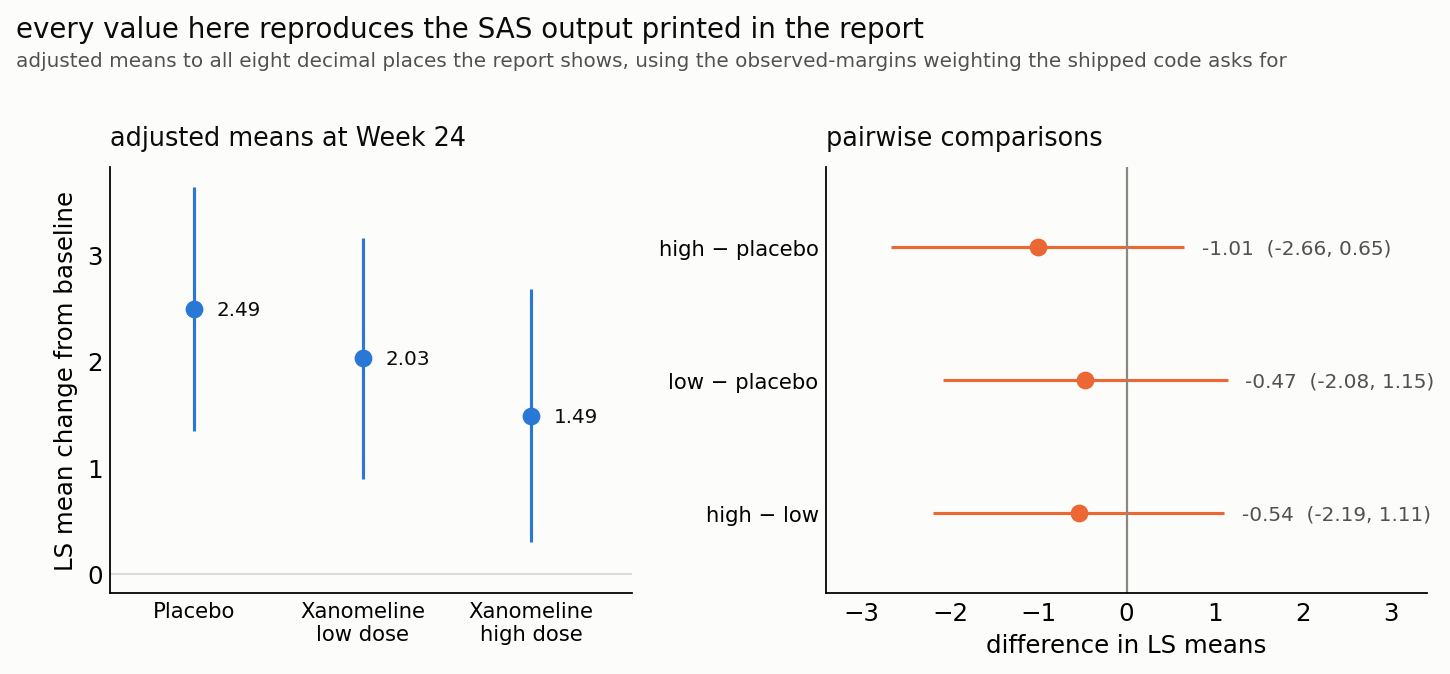

In [11]:
# Compute the least squares means two ways to find out which weighting the shipped code's
# /OM option actually asked for, then draw them.
levels = sorted(a.SITEGRP.unique())
design = comp.model.data.design_info

def ls_mean(trt, weights):
    """LSMEANS by hand: average the fitted surface over the site levels."""
    grid = pd.DataFrame({"TRTPCD": trt, "SITEGRP": levels, "BASE": a.BASE.mean()})
    M = np.asarray(dmatrix(design, grid))
    w = np.array([weights[l] for l in levels], dtype=float)
    contrast = (w / w.sum()) @ M
    est = contrast @ comp.params.values
    se = np.sqrt(contrast @ comp.cov_params().values @ contrast)
    half = stats.t.ppf(0.975, comp.df_resid) * se
    return est, se, est - half, est + half

equal_w = {l: 1.0 for l in levels}                          # LSMEANS default
om_w = a.SITEGRP.value_counts().to_dict()                    # LSMEANS / OM
SAS_LSM = {"H": (1.48854043, 0.60334071, 0.299473, 2.677608),
           "L": (2.02777167, 0.57490509, 0.894746, 3.160798),
           "P": (2.49455402, 0.58187565, 1.347790, 3.641318)}

print("least squares means for CHG, by treatment\n")
print(f"  {'':3s} {'equal weights':>24s} {'observed margins (/OM)':>26s} {'SAS output':>26s}")
LSM = {}
for trt in ("H", "L", "P"):
    e_eq, s_eq, *_ = ls_mean(trt, equal_w)
    e_om, s_om, lo, hi = ls_mean(trt, om_w)
    LSM[trt] = (e_om, s_om, lo, hi, e_eq, s_eq)
    print(f"  {trt:3s} {e_eq:12.8f} ({s_eq:.8f}) {e_om:12.8f} ({s_om:.8f}) "
          f"{SAS_LSM[trt][0]:12.8f} ({SAS_LSM[trt][1]:.8f})")
print("\n  /OM reproduces the printed values exactly; the default weighting does not.")
print("  That option is the one thing in the shipped code that had to be right,")
print("  and is.")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.2, 4.0),
                               gridspec_kw={"width_ratios": [1, 1.15]})

order = ["P", "L", "H"]
names = {"P": "Placebo", "L": "Xanomeline\nlow dose", "H": "Xanomeline\nhigh dose"}
x = np.arange(len(order))
om = np.array([LSM[t][0] for t in order])
lo = np.array([LSM[t][2] for t in order])
hi = np.array([LSM[t][3] for t in order])
eq = np.array([LSM[t][4] for t in order])

axL.vlines(x, lo, hi, color=BLUE, linewidth=1.4)
axL.plot(x, om, "o", color=BLUE, markersize=7)
axL.axhline(0, color="#dedcd6", linewidth=0.9, zorder=0)
axL.set_xticks(x); axL.set_xticklabels([names[t] for t in order], fontsize=9.5)
axL.set_xlim(-0.5, len(order) - 0.4)
axL.set_ylabel("LS mean change from baseline")
axL.set_title("adjusted means at Week 24", loc="left", fontsize=11.5, pad=10, color=INK)
for xi, v in zip(x, om):
    axL.annotate(f"{v:.2f}", (xi, v), textcoords="offset points", xytext=(10, -3),
                 fontsize=9, color=INK)

contrasts = [("H", "P", "high − placebo"), ("L", "P", "low − placebo"),
             ("H", "L", "high − low")]
y = np.arange(len(contrasts))[::-1]
for yi, (i, j, label) in zip(y, contrasts):
    k_i, k_j = f"C(TRTPCD)[T.{i}]", f"C(TRTPCD)[T.{j}]"
    cvec = np.zeros(len(comp.params))
    idx = comp.params.index.tolist()
    if k_i in idx:
        cvec[idx.index(k_i)] += 1
    if k_j in idx:
        cvec[idx.index(k_j)] -= 1
    tt = comp.t_test(cvec)
    est = float(np.ravel(tt.effect)[0])
    clo, chi = np.ravel(tt.conf_int())[:2]
    axR.hlines(yi, clo, chi, color=ORANGE, linewidth=1.4)
    axR.plot(est, yi, "o", color=ORANGE, markersize=7)
    axR.annotate(f"{est:.2f}  ({clo:.2f}, {chi:.2f})", (chi, yi),
                 textcoords="offset points", xytext=(8, -3), fontsize=9, color=INK2)
axR.axvline(0, color=MUTED, linewidth=1)
axR.set_yticks(y); axR.set_yticklabels([c[2] for c in contrasts], fontsize=9.5)
axR.set_ylim(-0.6, len(contrasts) - 0.4)
axR.set_xlim(-3.4, 3.4)
axR.set_xlabel("difference in LS means")
axR.set_title("pairwise comparisons", loc="left", fontsize=11.5, pad=10, color=INK)
for ax in (axL, axR):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("every value here reproduces the SAS output printed in the report",
             x=0.008, y=1.045, ha="left", fontsize=12.5, color=INK)
fig.text(0.008, 0.965, "adjusted means to all eight decimal places the report shows, "
         "using the observed-margins weighting the shipped code asks for",
         ha="left", fontsize=9, color=INK2)
fig.tight_layout()
fig.savefig(FIG / "02-ls-means.png", bbox_inches="tight")

## How far does the reproduction go?

Week 24 is one of three. The same ANCOVA was run at Weeks 8 and 16 and printed as tables
14-3.03 and 14-3.05, so the model can be refitted at each visit and checked against all
three.

In [12]:
# Refit the Week 24 model at Weeks 8 and 16, and check each against its own table.
VISITS = ["Week 8", "Week 16", "Week 24"]
# printed in CSR tables 14-3.03, 14-3.05 and 14-3.01
CSR_BY_VISIT = {
    "Week 8":  (0.497, {"low - placebo": (1.1, 0.65, 0.099),
                        "high - placebo": (0.2, 0.67, 0.751),
                        "high - low": (-0.9, 0.66, 0.195)}),
    "Week 16": (0.412, {"low - placebo": (-0.3, 0.77, 0.724),
                        "high - placebo": (-0.7, 0.79, 0.392),
                        "high - low": (None, None, 0.606)}),
    "Week 24": (0.245, {"low - placebo": (-0.5, 0.82, 0.569),
                        "high - placebo": (-1.0, 0.84, 0.233),
                        "high - low": (-0.5, 0.84, 0.520)}),
}
CONTRASTS = {"low - placebo": ("L", "P"), "high - placebo": ("H", "P"),
             "high - low": ("H", "L")}

def fit_visit(visit):
    v = ADAS[(ADAS.EFFFL == "Y") & (ADAS.ANL01FL == "Y")
             & (ADAS.AVISIT == visit) & (ADAS.PARAMCD == "ACTOT")].copy()
    v["SITEGRP"] = v.SITEGR1.astype(str)
    v["TRTPCD"] = v.TRTPN.map({0: "P", 54: "L", 81: "H"})
    return v, smf.ols("CHG ~ C(TRTPCD) + C(SITEGRP) + BASE", data=v).fit()

def contrast(model, i, j):
    idx = model.params.index.tolist()
    c = np.zeros(len(idx))
    for sign, lvl in ((1, i), (-1, j)):
        k = f"C(TRTPCD)[T.{lvl}]"
        if k in idx:
            c[idx.index(k)] += sign
    t = model.t_test(c)
    lo, hi = np.ravel(t.conf_int())[:2]
    return (float(np.ravel(t.effect)[0]), float(np.ravel(t.sd)[0]),
            float(np.ravel(t.pvalue)[0]), lo, hi)

OVER_TIME, models = {}, {}
print("the Week 24 model, refitted at each visit, against what each table prints\n")
for visit in VISITS:
    v, m = fit_visit(visit)
    models[visit] = (v, m)
    p_dose = sm.stats.anova_lm(
        smf.ols("CHG ~ TRTPN + C(SITEGRP) + BASE", data=v).fit(), typ=3
    ).loc["TRTPN", "PR(>F)"]
    want_p, want = CSR_BY_VISIT[visit]
    print(f"  {visit}   n = {len(v)}")
    print(f"    dose response p      {p_dose:6.3f}   CSR {want_p:.3f}"
          f"   {'ok' if abs(p_dose - want_p) < 6e-4 else 'DIFFERS'}")
    for label, (i, j) in CONTRASTS.items():
        est, se, p, lo, hi = contrast(m, i, j)
        OVER_TIME[(visit, label)] = (est, se, lo, hi)
        wd, ws, wp = want[label]
        ok = abs(p - wp) < 6e-4 and (wd is None or abs(round(est, 1) - wd) < 0.051)
        shown = "--" if wd is None else f"{wd:4.1f} ({ws:.2f})"
        print(f"    {label:20s} {est:6.2f} ({se:.2f})  p {p:.3f}   "
              f"CSR {shown:12s} p {wp:.3f}   {'ok' if ok else 'CHECK'}")
    print()

the Week 24 model, refitted at each visit, against what each table prints

  Week 8   n = 234
    dose response p       0.497   CSR 0.497   ok
    low - placebo          1.08 (0.65)  p 0.099   CSR  1.1 (0.65)  p 0.099   ok
    high - placebo         0.21 (0.67)  p 0.751   CSR  0.2 (0.67)  p 0.751   ok
    high - low            -0.86 (0.66)  p 0.195   CSR -0.9 (0.66)  p 0.195   ok

  Week 16   n = 234
    dose response p       0.412   CSR 0.412   ok
    low - placebo         -0.27 (0.77)  p 0.724   CSR -0.3 (0.77)  p 0.724   ok
    high - placebo        -0.68 (0.79)  p 0.392   CSR -0.7 (0.79)  p 0.392   ok
    high - low            -0.40 (0.78)  p 0.606   CSR --           p 0.606   ok

  Week 24   n = 234
    dose response p       0.245   CSR 0.245   ok
    low - placebo         -0.47 (0.82)  p 0.569   CSR -0.5 (0.82)  p 0.569   ok
    high - placebo        -1.01 (0.84)  p 0.233   CSR -1.0 (0.84)  p 0.233   ok
    high - low            -0.54 (0.84)  p 0.520   CSR -0.5 (0.84)  p 0.520   

Twelve checks, twelve matches. One analysis in this family is harder: table
14-3.11 is a repeated-measures model, and the report prints its PROC MIXED output too,
unstructured covariance, REML, Kenward-Roger degrees of freedom.

In [13]:
# Fit the repeated-measures model behind Table 14-3.11 and check it against PROC MIXED.
mm = ADAS[(ADAS.PARAMCD == "ACTOT") & (ADAS.EFFFL == "Y") & (ADAS.ANL01FL == "Y")
          & (ADAS.AVISIT.isin(VISITS)) & (ADAS.DTYPE == "")].copy()
mm["AWEEK"] = pd.Categorical(mm.AVISITN.astype(int).astype(str),
                             categories=["8", "16", "24"])
mm["SITEGRP"] = mm.SITEGR1.astype(str)
mm["TRT"] = mm.TRTPN.map({0: "0", 54: "1", 81: "2"})
print(f"observed cases: {len(mm)} rows, {mm.USUBJID.nunique()} subjects"
      f"   (SAS reports 539 and 234)\n")

mmrm = smf.mixedlm("CHG ~ C(TRT)*C(AWEEK) + C(SITEGRP) + BASE*C(AWEEK)",
                   data=mm, groups="USUBJID",
                   re_formula="0 + C(AWEEK)").fit(reml=True, method="lbfgs", maxiter=800)
marginal = np.asarray(mmrm.cov_re) + mmrm.scale * np.eye(3)
SAS_UN = {"UN(1,1)": (0, 0, 16.8209), "UN(2,1)": (1, 0, 11.2056), "UN(2,2)": (1, 1, 28.2581),
          "UN(3,1)": (2, 0, 11.8853), "UN(3,2)": (2, 1, 14.4451), "UN(3,3)": (2, 2, 31.3944)}
print("unstructured covariance — statsmodels splits this into a random-effect matrix")
print("plus a residual variance, so the diagonal needs the scale added back:\n")
for lab, (i, j, want) in SAS_UN.items():
    print(f"  {lab:9s} {marginal[i, j]:9.4f}   SAS {want:9.4f}")

weeks, sites = ["8", "16", "24"], sorted(mm.SITEGRP.unique())
mm_design = mmrm.model.data.design_info
def mmrm_lsmean(trt):
    grid = pd.DataFrame([(trt, w, s, mm.BASE.mean()) for w in weeks for s in sites],
                        columns=["TRT", "AWEEK", "SITEGRP", "BASE"])
    grid["AWEEK"] = pd.Categorical(grid.AWEEK, categories=weeks)
    M = np.asarray(dmatrix(mm_design, grid)).mean(axis=0)
    k = len(mmrm.fe_params)
    return (M @ mmrm.fe_params.values,
            np.sqrt(M @ mmrm.cov_params().values[:k, :k] @ M))

SAS_MMRM = {"0": (1.5535, 0.4930), "1": (1.5136, 0.5236), "2": (1.1270, 0.5552)}
print("\nLS means averaged over the three visits\n")
print(f"  {'':17s} {'notebook':>18s} {'SAS PROC MIXED':>18s}")
MMRM_LSM = {}
for trt, label in [("0", "placebo"), ("1", "low dose"), ("2", "high dose")]:
    est, se = mmrm_lsmean(trt)
    MMRM_LSM[label] = (est, se)
    print(f"  {label:17s} {est:8.4f} ({se:.4f}) {SAS_MMRM[trt][0]:10.4f} "
          f"({SAS_MMRM[trt][1]:.4f})")
print("\n  The estimates land on all four printed decimals. The standard errors sit")
print("  about 0.2% low, and the report says why: its Model Information block names")
print("  Kenward-Roger degrees of freedom and a Prasad-Rao-Jeske-Kackar-Harville")
print("  small-sample correction, neither of which statsmodels implements.")

observed cases: 539 rows, 234 subjects   (SAS reports 539 and 234)



unstructured covariance — statsmodels splits this into a random-effect matrix
plus a residual variance, so the diagonal needs the scale added back:

  UN(1,1)     16.8213   SAS   16.8209
  UN(2,1)     11.2060   SAS   11.2056
  UN(2,2)     28.2586   SAS   28.2581
  UN(3,1)     11.8851   SAS   11.8853
  UN(3,2)     14.4452   SAS   14.4451
  UN(3,3)     31.3947   SAS   31.3944

LS means averaged over the three visits

                              notebook     SAS PROC MIXED
  placebo             1.5535 (0.4924)     1.5535 (0.4930)
  low dose            1.5136 (0.5226)     1.5136 (0.5236)
  high dose           1.1270 (0.5541)     1.1270 (0.5552)

  The estimates land on all four printed decimals. The standard errors sit
  about 0.2% low, and the report says why: its Model Information block names
  Kenward-Roger degrees of freedom and a Prasad-Rao-Jeske-Kackar-Harville
  small-sample correction, neither of which statsmodels implements.


Those twelve numbers are worth seeing together. The plot below shows only
them, each treatment-minus-placebo difference with its interval, at each visit, because
each one has a printed counterpart. Per-arm adjusted means are left out on purpose: at
Weeks 8 and 16 the report prints none to check against, and the repeated-measures model
further down gives that trajectory properly.

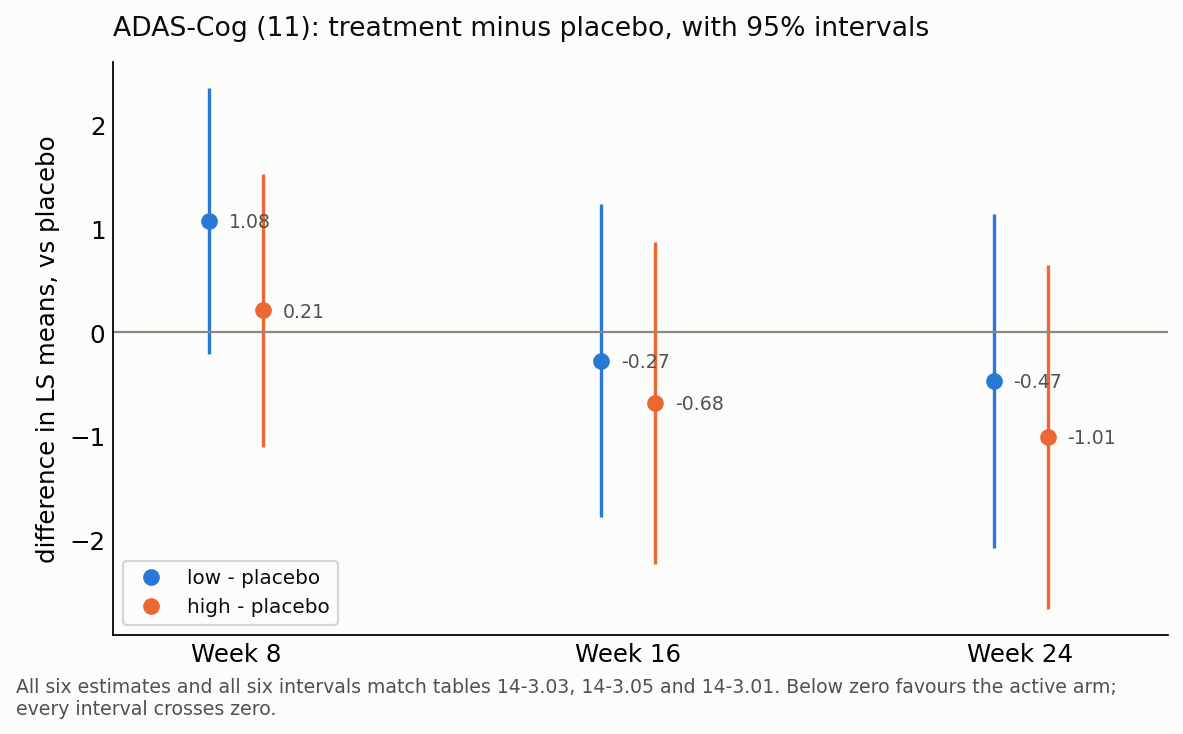

In [14]:
# Presentation only; every number plotted here was computed and checked in the cell above.
# The per-arm adjusted means are deliberately NOT drawn: at Weeks 8 and 16 the report
# prints no per-arm figure to check them against, and the MMRM further down gives the
# per-arm trajectory properly. This shows only what the three tables also show.
fig, ax = plt.subplots(figsize=(7.4, 4.4))
weeks_n = [8, 16, 24]
for label, colour, dx in [("low - placebo", BLUE, -0.55), ("high - placebo", ORANGE, 0.55)]:
    est = [OVER_TIME[(v, label)][0] for v in VISITS]
    lo = [OVER_TIME[(v, label)][2] for v in VISITS]
    hi = [OVER_TIME[(v, label)][3] for v in VISITS]
    xs = [w + dx for w in weeks_n]
    ax.vlines(xs, lo, hi, color=colour, linewidth=1.5)
    ax.plot(xs, est, "o", color=colour, markersize=6.5, label=label)
    for x, e in zip(xs, est):
        ax.annotate(f"{e:.2f}", (x, e), textcoords="offset points", xytext=(9, -3),
                    fontsize=8.5, color=INK2)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xticks(weeks_n); ax.set_xticklabels([f"Week {w}" for w in weeks_n])
ax.set_xlim(5.5, 27)
ax.set_ylabel("difference in LS means, vs placebo")
ax.set_title("ADAS-Cog (11): treatment minus placebo, with 95% intervals",
             loc="left", fontsize=12, pad=12, color=INK)
ax.legend(fontsize=9, loc="lower left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.tick_params(length=0)
fig.tight_layout()
fig.text(0.005, -0.03,
         "All six estimates and all six intervals match tables 14-3.03, 14-3.05 and "
         "14-3.01. Below zero favours the active arm;\nevery interval crosses zero.",
         ha="left", fontsize=8.5, color=INK2)
fig.savefig(FIG / "03-over-time.png", bbox_inches="tight")

The repeated-measures model gives a mean per arm per visit directly, since
it carries a treatment-by-visit interaction. Drawn the way a regulatory review would draw
it: black and white, every arm anchored at zero at baseline, error bars at one standard
error.

MMRM least squares means by arm and visit

                              Week 8           Week 16           Week 24
  Placebo               0.561 (0.480)      1.770 (0.645)      2.329 (0.689)
  Xanomeline low        1.612 (0.471)      1.193 (0.769)      1.735 (0.765)
  Xanomeline high       0.758 (0.495)      1.122 (0.796)      1.501 (0.832)

  Higher is worse on ADAS-Cog, so these rise. The over-time averages of these
  three curves are the values Table 14-3.11 prints, and they match exactly;
  the individual visit means are not printed anywhere.


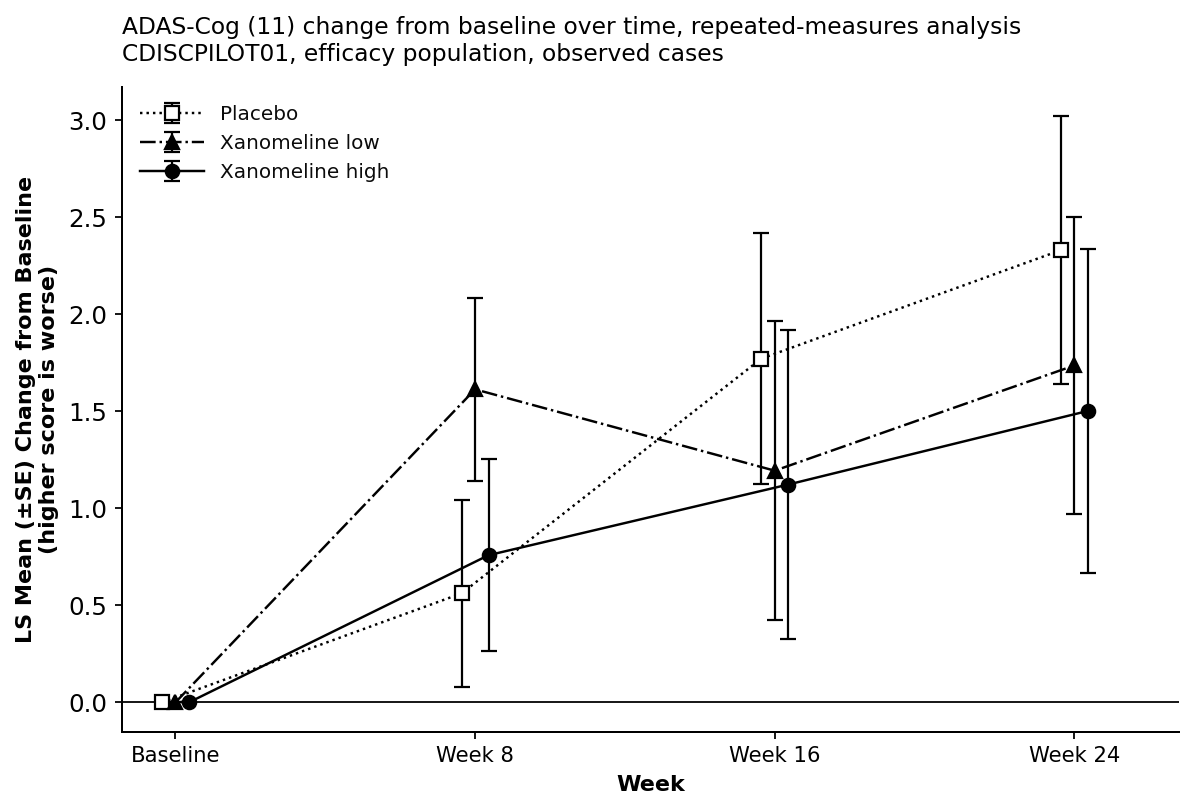

In [15]:
# Draw the MMRM trajectory in the style a regulatory review would use.
def mmrm_lsmean_at(trt, week=None):
    wk = weeks if week is None else [week]
    grid = pd.DataFrame([(trt, w, s, mm.BASE.mean()) for w in wk for s in sites],
                        columns=["TRT", "AWEEK", "SITEGRP", "BASE"])
    grid["AWEEK"] = pd.Categorical(grid.AWEEK, categories=weeks)
    M = np.asarray(dmatrix(mm_design, grid)).mean(axis=0)
    k = len(mmrm.fe_params)
    return (M @ mmrm.fe_params.values,
            np.sqrt(M @ mmrm.cov_params().values[:k, :k] @ M))

ARMS_BW = [
    ("0", "Placebo",           dict(linestyle=":",  marker="s", markerfacecolor="white")),
    ("1", "Xanomeline low",    dict(linestyle="-.", marker="^", markerfacecolor="black")),
    ("2", "Xanomeline high",   dict(linestyle="-",  marker="o", markerfacecolor="black")),
]
xpos = [0, 1, 2, 3]                       # Baseline, Week 8, Week 16, Week 24
labels = ["Baseline", "Week 8", "Week 16", "Week 24"]

print("MMRM least squares means by arm and visit\n")
print(f"  {'':16s}" + "".join(f"{w:>18s}" for w in labels[1:]))
fig, ax = plt.subplots(figsize=(7.6, 5.2), facecolor="white")
ax.set_facecolor("white")
for n, (trt, label, style) in enumerate(ARMS_BW):
    est = [0.0]; err = [0.0]
    for w in weeks:
        e, s = mmrm_lsmean_at(trt, w)
        est.append(e); err.append(s)
    print(f"  {label:16s}" + "".join(f"{e:11.3f} ({s:.3f})"
                                     for e, s in zip(est[1:], err[1:])))
    dx = (n - 1) * 0.045
    xs = [x + dx for x in xpos]
    ax.errorbar(xs, est, yerr=err, color="black", markersize=6,
                linewidth=1.1, elinewidth=1.0, capsize=3.5, label=label, **style)

ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=9.5)
ax.set_xlim(-0.18, 3.35)
ax.set_xlabel("Week", fontweight="bold", fontsize=10)
ax.set_ylabel("LS Mean (\u00b1SE) Change from Baseline\n(higher score is worse)",
              fontweight="bold", fontsize=10)
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(fontsize=9, loc="upper left", frameon=False, handlelength=3.2)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("black"); ax.spines[side].set_linewidth(0.9)
ax.tick_params(colors="black", length=3)
ax.set_title("ADAS-Cog (11) change from baseline over time, "
             "repeated-measures analysis\nCDISCPILOT01, efficacy population, "
             "observed cases",
             loc="left", fontsize=10.5, color="black", pad=12)
fig.tight_layout()
fig.savefig(FIG / "04-mmrm-trajectory.png", bbox_inches="tight", facecolor="white")
print("\n  Higher is worse on ADAS-Cog, so these rise. The over-time averages of these")
print("  three curves are the values Table 14-3.11 prints, and they match exactly;")
print("  the individual visit means are not printed anywhere.")

### Reading it the way the trial had to read it

This is the shape of figure a sponsor puts in front of a committee, so it is worth being
explicit about what it does and does not support.

**Nobody recovered.** All three curves rise, because ADAS-Cog measures deficit and
Alzheimer's is progressive. The question a trial like this asks is never whether subjects
improve; it is whether the treated arms climb more slowly than placebo. Read with a
"did the patient get better" frame, the figure says the drug failed and so did the placebo,
which is not what it says at all.

**The visual case for the drug, and why it does not hold.** At Week 24 both active arms sit
below placebo, 1.50 and 1.74 against 2.33, i.e. roughly a point less worsening. That is the
direction a sponsor wants and it is the reason this figure gets made. None of it reaches
significance: the repeated-measures Type 3 test for treatment gives p = 0.8184, the
treatment-by-visit interaction p = 0.2926, and the Week 24 dose-response ANCOVA p = 0.245,
with every pairwise comparison above 0.2. There is also no dose ordering, at Week 8 the low
dose is the *worst* of the three arms, and the curves cross twice. A real dose response is
monotone and stays monotone.

**The gap at Week 24 is what differential dropout looks like.** 30% of placebo subjects left
before Week 24, against 64% and 67% of the two active arms, and the reason was overwhelmingly
adverse events, 8 placebo subjects against 40 and 44. This figure is observed cases, so the
denominator shrinks unevenly underneath it: at Week 24 placebo still contributes 65 of its
79, the active arms 41 of 74 and 49 of 81. Whoever is left in the active arms is, by
construction, the half that tolerated the drug. A curve drawn over a shrinking self-selected
denominator drifts toward those people whether or not the drug does anything, which is
exactly the separation visible at the right-hand edge. It is also why the primary analysis
was LOCF rather than observed cases, and why the report's own conclusion says the
discontinuation "further hindered the study's ability to demonstrate efficacy."

**And the figure does not carry the number you need to see that.** The n per arm per visit
is not on the plot. Neither is the reason people left. Both live somewhere else in the
package, in the disposition data, in `DTYPE`, in the SAP's choice of imputation, which is
the same shape as everything above: the values do not tell you what they are, and the
metadata beside them does.

## Down to the tabulation and the form

The analysis row carries `QSSEQ`, a pointer to the SDTM record it came from. Follow it.

In [16]:
# Follow one analysis row down to the SDTM record it points at, then to the item scores
# that record was built from.
QS = read_dataset_json(DATA / "sdtm" / "qs.json")
row = wk24[wk24.DTYPE == "LOCF"].sort_values("USUBJID").iloc[0]
print("one LOCF analysis row from ADQSADAS")
print(row[["USUBJID", "PARAMCD", "AVISIT", "VISIT", "ADT",
           "AVAL", "BASE", "CHG", "DTYPE", "QSSEQ"]].to_string(), "\n")

src = QS[(QS.USUBJID == row.USUBJID) & (QS.QSSEQ == row.QSSEQ)]
print(f"SDTM QS record it points at (QSSEQ={row.QSSEQ})")
print(src[["USUBJID", "QSSEQ", "QSTESTCD", "QSTEST", "VISIT",
           "QSDTC", "QSORRES", "QSSTRESN", "QSDRVFL"]].to_string(index=False), "\n")

visit = QS[(QS.USUBJID == row.USUBJID) & (QS.VISITNUM == src.VISITNUM.iloc[0])
           & (QS.QSTESTCD.str.startswith("ACITM"))]
print(f"the {len(visit)} collected item records at that visit")
print(visit[["QSSEQ", "QSTESTCD", "QSTEST", "QSORRES", "QSSTRESN"]].to_string(index=False))
total = src.QSSTRESN.iloc[0]
print(f"\nsum of all {len(visit)} items = {visit.QSSTRESN.sum():.0f}"
      f"   but the derived ACTOT record = {total:.0f}")

# One record alone does not pin the rule down — several subsets hit 10, because most of
# the items scored 0. Solve it across every ACTOT record in the study instead.
ac = QS[QS.QSTESTCD.str.startswith("AC")]
wide = ac.pivot_table(index=["USUBJID", "VISITNUM"], columns="QSTESTCD",
                      values="QSSTRESN", aggfunc="first")
items = sorted(col for col in wide.columns if col.startswith("ACITM"))
complete = wide.dropna(subset=items + ["ACTOT"])
print(f"\n{len(complete):,} visits have all {len(items)} items and a derived ACTOT")

solutions = []
for drop in itertools.combinations(items, len(items) - 11):
    keep = [i for i in items if i not in drop]
    if (complete[keep].sum(axis=1) - complete["ACTOT"]).abs().max() < 1e-9:
        solutions.append(drop)
print(f"11-item subsets that reproduce ACTOT on every one of them: {len(solutions)}")
for drop in solutions:
    print("  excluded:")
    for k in drop:
        print(f"    {k}  {ac[ac.QSTESTCD == k].QSTEST.iloc[0].title()}")

sdtm_def = ET.parse(DATA / "sdtm" / "define.xml").getroot()
print("\nwhat the SDTM define.xml says about these:")
for it in sdtm_def.iter():
    if tag(it) == "ItemDef" and attr(it, "Name") in ("QSORRES", "QSSTRESN", "QSDRVFL"):
        origin, comment = attr(it, "Origin") or "", attr(it, "Comment") or ""
        print(f"  {attr(it,'Name'):9s} Origin={origin[:46]}"
              f"{'...' if len(origin) > 46 else ''}")
        if comment.strip():
            print(f"            Comment={comment.strip()}")
print(f"\n'ACTOT' appears in the SDTM define.xml "
      f"{(DATA/'sdtm'/'define.xml').read_text().count('ACTOT')} times "
      f"(as a QSTESTCD codelist entry; no composition rule)")

one LOCF analysis row from ADQSADAS
USUBJID    01-701-1146
PARAMCD          ACTOT
AVISIT         Week 24
VISIT           WEEK 6
ADT         2013-06-30
AVAL              10.0
BASE              11.0
CHG               -1.0
DTYPE             LOCF
QSSEQ             5030 

SDTM QS record it points at (QSSEQ=5030)
    USUBJID  QSSEQ QSTESTCD                QSTEST  VISIT      QSDTC QSORRES  QSSTRESN QSDRVFL
01-701-1146   5030    ACTOT ADAS-COG(11) Subscore WEEK 6 2013-06-30              10.0       Y 

the 14 collected item records at that visit
 QSSEQ QSTESTCD                                   QSTEST QSORRES  QSSTRESN
  5016  ACITM01                         WORD RECALL TASK       4       4.0
  5017  ACITM02 NAMING OBJECTS AND FINGERS (REFER TO 5 C       0       0.0
  5018  ACITM03                      DELAYED WORD RECALL       9       9.0
  5019  ACITM04                                 COMMANDS       0       0.0
  5020  ACITM05                    CONSTRUCTIONAL PRAXIS       0       0.0
  5021 

One record does not pin the composition rule down, because most items scored
zero. Solving across every visit in the study does, and the answer is unique, but it was
recovered by arithmetic, not read from the package.

## The chain, and where the descriptions stop matching

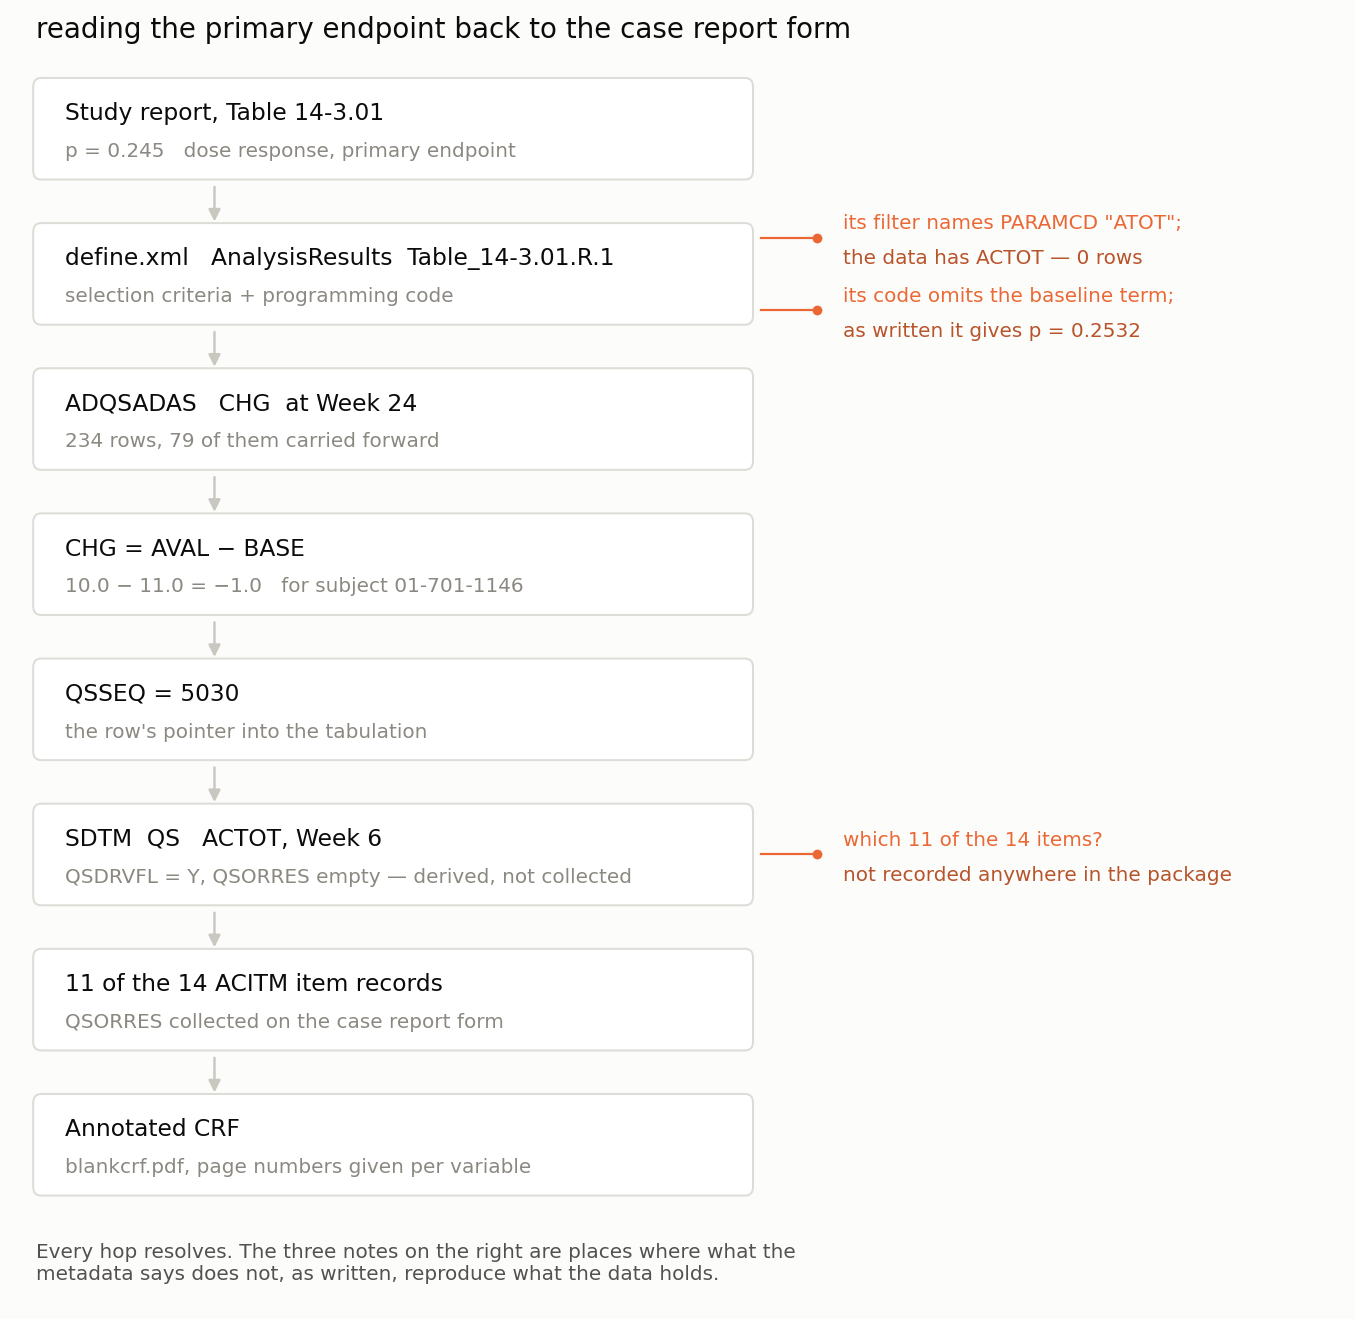

In [17]:
# Presentation only. Draws the whole trace as one picture, with the three
# places the metadata and the data disagree marked on the side.
# (heading, detail) top to bottom
CHAIN = [
    ("Study report, Table 14-3.01", "p = 0.245   dose response, primary endpoint"),
    ("define.xml   AnalysisResults  Table_14-3.01.R.1", "selection criteria + programming code"),
    ("ADQSADAS   CHG  at Week 24", "234 rows, 79 of them carried forward"),
    ("CHG = AVAL − BASE", "10.0 − 11.0 = −1.0   for subject 01-701-1146"),
    ("QSSEQ = 5030", "the row's pointer into the tabulation"),
    ("SDTM  QS   ACTOT, Week 6", "QSDRVFL = Y, QSORRES empty — derived, not collected"),
    ("11 of the 14 ACITM item records", "QSORRES collected on the case report form"),
    ("Annotated CRF", "blankcrf.pdf, page numbers given per variable"),
]

# (node index, vertical offset within that node's row, lines)
GAPS = [
    (1, 0.64, ["its filter names PARAMCD \"ATOT\";", "the data has ACTOT — 0 rows"]),
    (1, 0.14, ["its code omits the baseline term;", "as written it gives p = 0.2532"]),
    (5, 0.39, ["which 11 of the 14 items?", "not recorded anywhere in the package"]),
]

n = len(CHAIN)
fig, ax = plt.subplots(figsize=(8.6, 8.4))
ax.set_xlim(0, 10); ax.set_ylim(-0.7, n + 0.1); ax.axis("off")

BOX_L, BOX_R = 0.15, 5.55
for i, (head, detail) in enumerate(CHAIN):
    y = n - 1 - i
    ax.add_patch(FancyBboxPatch(
        (BOX_L, y + 0.06), BOX_R - BOX_L, 0.66,
        boxstyle="round,pad=0.02,rounding_size=0.06",
        linewidth=0.9, edgecolor="#dedcd6", facecolor="#ffffff"))
    ax.text(BOX_L + 0.22, y + 0.50, head, fontsize=10.5, color=INK, va="center")
    ax.text(BOX_L + 0.22, y + 0.24, detail, fontsize=9, color=MUTED, va="center")
    if i < n - 1:
        ax.annotate("", xy=(1.5, y + 0.02), xytext=(1.5, y - 0.28),
                    arrowprops=dict(arrowstyle="<|-", color="#c9c7c0",
                                    linewidth=1.1, mutation_scale=11))

for i, dy, lines in GAPS:
    y = n - 1 - i + dy
    ax.plot([BOX_R + 0.08, 6.05], [y, y], color=ORANGE, linewidth=1, zorder=1)
    ax.plot([6.05], [y], marker="o", markersize=3.4, color=ORANGE, zorder=2)
    for j, line in enumerate(lines):
        ax.text(6.25, y + 0.10 - j * 0.24, line, fontsize=9,
                color=ORANGE if j == 0 else "#b8532a", va="center")

ax.text(BOX_L, n - 0.02, "reading the primary endpoint back to the case report form",
        fontsize=12.5, color=INK, va="bottom")
ax.text(BOX_L, -0.42,
        "Every hop resolves. The three notes on the right are places where what the\n"
        "metadata says does not, as written, reproduce what the data holds.",
        fontsize=9, color=INK2, va="center")

fig.tight_layout()
fig.savefig(FIG / "01-the-chain.png", bbox_inches="tight")

## A label that answers a different question than the one you asked

Before sorting columns, one worked example of why the sorting cannot be done from names.

The analysis above selected `AVISIT == "Week 24"`, and the numbers came out right, so the
filter was correct. But it is worth asking what that label actually gathered up.

In [18]:
# Count what the analysis label 'Week 24' actually selects, against the visit each
# measurement was recorded at.
# AVISIT is the analysis timepoint; VISIT is what the visit was called on the day. Both are
# columns of ADQSADAS, sitting next to each other. Filtering on one never shows you the other.
w24 = ADAS[(ADAS.PARAMCD == "ACTOT") & (ADAS.AVISIT == "Week 24")
           & (ADAS.ANL01FL == "Y") & (ADAS.EFFFL == "Y")]
print(f"{len(w24)} analysis rows carry AVISIT = 'Week 24'\n")
print(pd.crosstab(w24.VISIT, w24.DTYPE.replace("", "(observed)"), margins=True).to_string())
print(f"\n  named WEEK 24 on the day : {(w24.VISIT == 'WEEK 24').sum()}")
print(f"  something else           : {(w24.VISIT != 'WEEK 24').sum()}")

234 analysis rows carry AVISIT = 'Week 24'

DTYPE              (observed)  LOCF  All
VISIT                                   
AMBUL ECG REMOVAL           0     1    1
RETRIEVAL                  37     0   37
WEEK 12                     0    16   16
WEEK 16                     1    14   15
WEEK 2                      0    11   11
WEEK 20                     2     4    6
WEEK 24                   115     0  115
WEEK 4                      0     5    5
WEEK 6                      0    11   11
WEEK 8                      0    17   17
All                       155    79  234

  named WEEK 24 on the day : 115
  something else           : 119


Only 115 of the 234 were recorded at a visit called Week 24. Here is why, from
the dataset's own windowing columns.

In [19]:
# Read the windowing rule out of the dataset itself, and separate the two mechanisms.
# Nothing here is inferred. The dataset carries its own windowing rule, once per row.
print("the analysis window, as ADQSADAS states it on these rows:")
for c in ("AWRANGE", "AWTARGET", "AWLO", "AWHI", "AWU"):
    vals = [v for v in w24[c].unique() if str(v) not in ("nan", "")]
    print(f"  {c:9s} {vals}")

print("\nstudy day of the measurement actually behind each row:")
print(w24.groupby(w24.DTYPE.replace("", "(observed)")).ADY
         .agg(["count", "min", "max"]).to_string())
print("""
Two different things put a row here, and only one of them is imputation.

  observed   any assessment on study day 141 or later is the Week 24 analysis point,
             whatever the visit was called. That is why RETRIEVAL contributes 37 rows.
  LOCF       the subject stopped coming, so their last observed value is carried
             forward. Those measurements are all from day 140 or earlier.

AVISIT is not wrong. It answers "which analysis timepoint is this row", and every one of
these rows genuinely is that subject's Week 24 analysis value; for an LOCF analysis that is
the whole point. It only misleads when you read it as "when was this measured", which is a
different question, answered by the column beside it.""")

the analysis window, as ADQSADAS states it on these rows:
  AWRANGE   ['>140']
  AWTARGET  [np.int64(168)]
  AWLO      [np.float64(141.0)]
  AWHI      []
  AWU       ['DAYS']

study day of the measurement actually behind each row:
            count  min  max
DTYPE                      
(observed)    155  141  286
LOCF           79    5  140

Two different things put a row here, and only one of them is imputation.

  observed   any assessment on study day 141 or later is the Week 24 analysis point,
             whatever the visit was called. That is why RETRIEVAL contributes 37 rows.
  LOCF       the subject stopped coming, so their last observed value is carried
             forward. Those measurements are all from day 140 or earlier.

AVISIT is not wrong. It answers "which analysis timepoint is this row", and every one of
these rows genuinely is that subject's Week 24 analysis value; for an LOCF analysis that is
the whole point. It only misleads when you read it as "when was this meas

## So what do you actually model?

Everything above was about checking one number. The reason to do that work is that it tells
you what the columns *are*, and that is the question you have to answer before any of this
becomes a training set.

ADSL is one row per subject, 48 columns, no missing-data mess. It looks like a feature table
someone already cleaned for you. It is not one, and `define.xml` says so if you read it.

Start with the field that ought to answer the question outright.

In [20]:
# Read every variable definition out of both define.xml files.
def item_table(path, groups):
    root = ET.parse(path).getroot()
    ids = {attr(d, "OID"): d for d in root.iter() if tag(d) == "ItemDef"}
    out = []
    for g in root.iter():
        if tag(g) != "ItemGroupDef" or attr(g, "Name") not in groups:
            continue
        for ref in g:
            if tag(ref) != "ItemRef":
                continue
            d = ids[attr(ref, "ItemOID")]
            out.append({"dataset": attr(g, "Name"), "variable": attr(d, "Name"),
                        "label": (attr(d, "Label") or "").strip(),
                        "origin": (attr(d, "Origin") or "").strip(),
                        "comment": " ".join((attr(d, "Comment") or "").split())})
    return pd.DataFrame(out)

adam_items = item_table(DATA / "adam" / "define.xml", {"ADSL", "ADQSADAS"})
sdtm_items = item_table(DATA / "sdtm" / "define.xml",
                        {"DM", "VS", "SC", "MH", "EX", "DS", "SV", "QS"})
SDTM_ORIGIN = {f"{r.dataset}.{r.variable}": r.origin for r in sdtm_items.itertuples()}
ANALYSED = {attr(v, "ItemOID") for v in define_adam.iter()
            if tag(v) == "AnalysisVariable"}

print(f"{len(adam_items)} columns across ADSL and ADQSADAS")
print(f"distinct values of Origin in the ADaM define.xml: "
      f"{adam_items.origin.unique().tolist()}")
print(f"distinct values of Origin in the SDTM define.xml: "
      f"{sorted({o.split(' Page')[0] for o in sdtm_items.origin})}")
print("\nSo at the ADaM level the machine-readable provenance field says the same thing")
print("about every column. What varies is the free-text Comment.")

88 columns across ADSL and ADQSADAS
distinct values of Origin in the ADaM define.xml: ['Derived']
distinct values of Origin in the SDTM define.xml: ['Assigned', 'CRF', 'Derived', 'eDT']

So at the ADaM level the machine-readable provenance field says the same thing
about every column. What varies is the free-text Comment.


`Origin` discriminates in the tabulations and not in the analysis datasets. So
the sorting below leans on the `Comment` text, on which variables the analysis results
metadata names, and, where neither settles it, on when the value could first have been
known. Three buckets:

- **technical**, identifiers, pointers, visit windows, record flags. Needed to join and
  filter rows; carries nothing about a subject.
- **result**, anything determined by what happened after randomisation. Endpoints, but also
  exposure, disposition and every population flag.
- **feature**, fixed at or before randomisation, so legitimately an input.

In [21]:
# Sort all 88 columns into technical / result / feature, and write column-roles.csv.
# Bookkeeping: needed to join, filter and identify rows; no information about a subject.
TECHNICAL = {"STUDYID","USUBJID","SUBJID","SITEID","QSSEQ","PARAM","PARAMCD","PARAMN",
             "AVISIT","AVISITN","VISIT","VISITNUM","ADY","ADT","ABLFL","ANL01FL","DTYPE",
             "AWRANGE","AWTARGET","AWTDIFF","AWLO","AWHI","AWU","AGEU","ITTFL"}
# Determined by what happened after randomisation. Never an input to predicting outcome.
RESULT = {"AVAL","CHG","PCHG","TRT01A","TRT01AN","TRTEDT","TRTDUR","AVGDD","CUMDOSE",
          "SAFFL","EFFFL","COMP8FL","COMP16FL","COMP24FL","DISCONFL","DSRAEFL","DTHFL",
          "RFENDTC","RFENDT","VISNUMEN","DCDECOD","DCREASCD"}
WHY = {
 "AVAL": "the analysed value itself",
 "CHG": "the endpoint — AVAL minus BASE",
 "PCHG": "the endpoint on a relative scale",
 "BASE": "pre-dose ADAS-Cog at visit 3; a covariate in the sponsor's own model, so an input",
 "TRT01A": "actual treatment is knowable only after dosing (identical to planned here)",
 "TRT01AN": "numeric twin of TRT01A",
 "TRTEDT": "date of last dose — encodes when the subject stopped",
 "TRTDUR": "TRTEDT-TRTSDT+1, so it encodes time on drug, i.e. discontinuation",
 "AVGDD": "CUMDOSE/TRTDUR — inherits TRTDUR",
 "CUMDOSE": "accumulates over time on drug",
 "SAFFL": "requires a non-missing treatment start date",
 "EFFFL": "requires post-baseline ADAS-Cog and CIBIC+ records to exist",
 "COMP8FL": "completion status at week 8",
 "COMP16FL": "completion status at week 16",
 "COMP24FL": "completion status at week 24 — the discontinuation outcome in disguise",
 "DISCONFL": "discontinuation outcome",
 "DSRAEFL": "discontinued because of an adverse event",
 "DTHFL": "death",
 "RFENDTC": "end-of-participation date",
 "RFENDT": "numeric form of RFENDTC",
 "VISNUMEN": "last on-treatment visit",
 "DCDECOD": "why the subject left the study",
 "DCREASCD": "why the subject left, pooled into categories",
 "ARM": "randomised assignment; same content as TRT01P",
 "TRT01P": "randomised assignment — the intervention, fixed before any outcome",
 "TRT01PN": "numeric twin of TRT01P",
 "TRTP": "randomised assignment carried down from ADSL",
 "TRTPN": "numeric twin of TRTP; the dose term in the sponsor's model",
 "TRTSDT": "first dose date, fixed at the start",
 "SITEGR1": "pooled site — a design variable and a factor in the sponsor's model",
 "MMSETOT": "screening MMSE, collected before randomisation",
 "AGEGR1": "banded AGE", "AGEGR1N": "numeric twin of AGEGR1",
 "RACEN": "numeric twin of RACE", "BMIBL": "from baseline height and weight",
 "BMIBLGR1": "banded BMIBL", "DURDSGR1": "banded DURDIS",
 "ITTFL": "'Y if ARMCD ne blank' — true for everyone randomised, so it selects rather than informs",
}
SRC = re.compile(r"\b([A-Z]{2,8})\.([A-Z0-9]+)\b")

def classify(v):
    return "technical" if v in TECHNICAL else "result" if v in RESULT else "feature"

records = []
for r in adam_items.itertuples():
    m = SRC.search(r.comment or "")
    src = f"{m.group(1)}.{m.group(2)}" if m else ""
    where = ("(inherits ADSL)" if src.startswith("ADSL.")
             else SDTM_ORIGIN.get(src, "" if not src else "not in the SDTM define"))
    records.append({
        "dataset": r.dataset, "variable": r.variable, "label": r.label,
        "role": classify(r.variable),
        "named_in_analysis_metadata": "yes" if f"{r.dataset}.{r.variable}" in ANALYSED else "",
        "why": WHY.get(r.variable, ""),
        "how_define_xml_says_it_was_made": r.comment,
        "traces_to": src, "where_in_the_source": where,
    })
COLUMNS = pd.DataFrame(records)
COLUMNS.to_csv("column-roles.csv", index=False)

print(COLUMNS.groupby(["dataset", "role"]).size().unstack(fill_value=0).to_string())
print()
for ds in ("ADSL", "ADQSADAS"):
    sub = COLUMNS[COLUMNS.dataset == ds]
    print(f"{ds} — {len(sub)} columns")
    for rl in ("feature", "result", "technical"):
        v = sub[sub.role == rl].variable.tolist()
        print(f"  {rl:10s} {len(v):2d}   {', '.join(v)}")
    print()
n_res = (COLUMNS[COLUMNS.dataset == "ADSL"].role == "result").sum()
print(f"ADSL is one row per subject and looks like a ready-made feature table.")
print(f"{n_res} of its 48 columns describe what happened after randomisation.")

role      feature  result  technical
dataset                             
ADQSADAS       11       6         23
ADSL           23      19          6

ADSL — 48 columns
  feature    23   SITEGR1, ARM, TRT01P, TRT01PN, TRTSDT, AGE, AGEGR1, AGEGR1N, RACE, RACEN, SEX, ETHNIC, BMIBL, BMIBLGR1, HEIGHTBL, WEIGHTBL, EDUCLVL, DISONSDT, DURDIS, DURDSGR1, VISIT1DT, RFSTDTC, MMSETOT
  result     19   TRT01A, TRT01AN, TRTEDT, TRTDUR, AVGDD, CUMDOSE, SAFFL, EFFFL, COMP8FL, COMP16FL, COMP24FL, DISCONFL, DSRAEFL, DTHFL, RFENDTC, VISNUMEN, RFENDT, DCDECOD, DCREASCD
  technical   6   STUDYID, USUBJID, SUBJID, SITEID, AGEU, ITTFL

ADQSADAS — 40 columns
  feature    11   SITEGR1, TRTSDT, TRTP, TRTPN, AGE, AGEGR1, AGEGR1N, RACE, RACEN, SEX, BASE
  result      6   TRTEDT, EFFFL, COMP24FL, AVAL, CHG, PCHG
  technical  23   STUDYID, SITEID, USUBJID, ITTFL, AVISIT, AVISITN, VISIT, VISITNUM, ADY, ADT, PARAM, PARAMCD, PARAMN, ABLFL, ANL01FL, DTYPE, AWRANGE, AWTARGET, AWTDIFF, AWLO, AWHI, AWU, QSSEQ

ADSL is one r

Nineteen of ADSL's 48 columns are results. Several of them do not look like
results at all: `TRTDUR` is a duration, `COMP24FL` is a Y/N flag, `AVGDD` is a dose. Each one
is a function of when the subject stopped, which is exactly what a dropout or outcome model
would be trying to predict.

The evidence for each is a sentence of `define.xml` prose, so here it is alongside the
verdict.

In [22]:
# Show the result columns with the define.xml sentence each verdict rests on.
# The verdict, then the sentence of define.xml it rests on. Nothing here is inferred
# from the values — only from what the document states about how each column was made.
res = COLUMNS[(COLUMNS.role == "result") & (COLUMNS.dataset == "ADSL")]
print(f"the {len(res)} ADSL columns that are results\n")
for r in res.itertuples():
    print(f"  {r.variable:9s} {r.why}")

# The five that look least like results are the ones worth quoting the evidence for.
print("\n\nthe least obvious of them, and what define.xml states outright\n")
for v in ("TRTDUR", "AVGDD", "CUMDOSE", "COMP24FL", "EFFFL"):
    row = res[res.variable == v].iloc[0]
    print(f"  {v}")
    print(f"    {row.how_define_xml_says_it_was_made[:104]}")

print("\n\nfor contrast — the features whose trace reaches a page of the case report form\n")
feat = COLUMNS[(COLUMNS.role == "feature")
               & COLUMNS.where_in_the_source.str.startswith("CRF")]
for r in feat.itertuples():
    print(f"  {r.dataset}.{r.variable:9s} -> {r.traces_to:12s} -> "
          f"{r.where_in_the_source[:58]}")
print(f"\n  {len(feat)} of {len(COLUMNS)} columns get that far. For the rest the trail")
print("  ends inside SDTM, because the SDTM value is itself derived.")
print("\nwritten to column-roles.csv")

# a reference the define.xml makes but the package cannot satisfy
known = {f"{d}.{v}" for d, v in zip(adam_items.dataset, adam_items.variable)}
dangling = [(r.dataset, r.variable, r.traces_to) for r in COLUMNS.itertuples()
            if r.traces_to.startswith("ADSL.") and r.traces_to not in known]
print("\npredecessor references that do not resolve:")
for ds, v, t in dangling:
    print(f"  {ds}.{v} says its predecessor is {t}, which is not in ADSL")

the 19 ADSL columns that are results

  TRT01A    actual treatment is knowable only after dosing (identical to planned here)
  TRT01AN   numeric twin of TRT01A
  TRTEDT    date of last dose — encodes when the subject stopped
  TRTDUR    TRTEDT-TRTSDT+1, so it encodes time on drug, i.e. discontinuation
  AVGDD     CUMDOSE/TRTDUR — inherits TRTDUR
  CUMDOSE   accumulates over time on drug
  SAFFL     requires a non-missing treatment start date
  EFFFL     requires post-baseline ADAS-Cog and CIBIC+ records to exist
  COMP8FL   completion status at week 8
  COMP16FL  completion status at week 16
  COMP24FL  completion status at week 24 — the discontinuation outcome in disguise
  DISCONFL  discontinuation outcome
  DSRAEFL   discontinued because of an adverse event
  DTHFL     death
  RFENDTC   end-of-participation date
  VISNUMEN  last on-treatment visit
  RFENDT    numeric form of RFENDTC
  DCDECOD   why the subject left the study
  DCREASCD  why the subject left, pooled into categories



`column-roles.csv` has all 88 rows: dataset, variable, label, role, why, the
derivation `define.xml` states, what it traces to, and where that lands in the source.

Two things to carry out of it. The `where_in_the_source` column is blank or `Derived` more
often than it is a CRF page, the trace reaches SDTM and stops, because the SDTM value is
itself derived, the same wall `ACTOT` ran into earlier. And one predecessor reference points
at a variable that does not exist, which is the third dangling reference in this package and
the reason to run these checks rather than read the document and believe it.

## The table you would actually train on

Sorting the columns is the work; the deliverable is a flat table that carries the sorting
with it. One row per randomised subject, one column per measurement, and each visit of a
repeated measure in its own column.

Three efficacy endpoints go in wide, ADAS-Cog (11), CIBIC+ and NPI-X, at the visits the
report analyses them at, taking the record each analysis used (`ANL01FL='Y'`). Where a
value was carried forward rather than observed, that gets its own column, because "this
subject had no visit in the window" is information, not a blemish.

In [23]:
# Reshape the three efficacy endpoints into one row per subject, one column per visit.
ADSL_DF = adam("ADSL")
CIBC = adam("ADQSCIBC")
NPIX_DF = adam("ADQSNPIX")

# The three efficacy endpoints, at the visits the report analyses them at.
# (endpoint prefix, dataset, PARAMCD, measures to pull, visits)
ENDPOINTS = [
    ("ADAS",  ADAS,     "ACTOT",    ["AVAL", "CHG"], ["Baseline", "Week 8", "Week 16", "Week 24"]),
    ("CIBIC", CIBC,     "CIBICVAL", ["AVAL"],        ["Week 8", "Week 16", "Week 24"]),
    ("NPI",   NPIX_DF,  "NPTOT",    ["AVAL", "CHG"], ["Baseline", "Week 8", "Week 16", "Week 24"]),
    ("NPI",   NPIX_DF,  "NPTOTMN",  ["AVAL"],        ["Weeks 4-24"]),
]
SUFFIX = {"Baseline": "BASE", "Week 8": "W08", "Week 16": "W16", "Week 24": "W24",
          "Weeks 4-24": "W04_24"}

wide = ADSL_DF.set_index("USUBJID").copy()
long_meta = []
for prefix, src, paramcd, measures, visits in ENDPOINTS:
    d = src[(src.PARAMCD == paramcd) & (src.ANL01FL == "Y")].copy()
    d["VIS"] = d.AVISIT.str.strip()          # NPI-X pads its visit labels
    d = d[d.VIS.isin(visits)]
    dup = d.duplicated(["USUBJID", "VIS"]).sum()
    if dup:
        raise ValueError(f"{prefix}/{paramcd}: {dup} duplicate subject-visit rows")
    for visit in visits:
        v = d[d.VIS == visit].set_index("USUBJID")
        tag_ = SUFFIX[visit]
        for meas in measures:
            if meas not in v.columns:
                continue
            if meas == "CHG" and visit == "Baseline":
                continue                     # change from baseline at baseline is zero
            col = f"{prefix}_{meas}_{tag_}"
            wide[col] = v[meas]
            long_meta.append((col, prefix, paramcd, meas, visit))
        if "DTYPE" in v.columns:
            flag = (v.DTYPE.reindex(wide.index) == "LOCF").astype("Int64")
            if flag.nunique() > 1:           # NPI-X carries no LOCF, so no flag for it
                col = f"{prefix}_LOCF_{tag_}"
                wide[col] = flag
                long_meta.append((col, prefix, paramcd, "DTYPE", visit))

wide = wide.reset_index()
print(f"{len(wide)} rows (one per randomised subject), {wide.shape[1]} columns\n")

# self-check against the numbers the report prints
eff = wide[wide.EFFFL == "Y"]
print(f"  subjects with EFFFL='Y'                     {len(eff):4d}   report: 234")
print(f"  non-missing ADAS_CHG_W24 among those        "
      f"{eff.ADAS_CHG_W24.notna().sum():4d}   report: 234")
print(f"  of those, carried forward                   "
      f"{int(eff.ADAS_LOCF_W24.sum()):4d}   notebook earlier: 79")
print(f"  mean ADAS_CHG_W24 by arm  "
      f"{eff.groupby('TRT01PN').ADAS_CHG_W24.mean().round(2).to_dict()}")
print(f"                            report: 2.5 placebo, 2.0 low, 1.5 high")

254 rows (one per randomised subject), 71 columns

  subjects with EFFFL='Y'                      234   report: 234
  non-missing ADAS_CHG_W24 among those         234   report: 234
  of those, carried forward                     79   notebook earlier: 79
  mean ADAS_CHG_W24 by arm  {0: 2.54, 54: 2.0, 81: 1.47}
                            report: 2.5 placebo, 2.0 low, 1.5 high


The row count and the Week 24 means match what the report prints, so the
reshaping did not lose or duplicate anyone. Now the dictionary that travels with it.

In [24]:
# Write the column dictionary that travels with the table.
ROLE_BY_VAR = dict(zip(COLUMNS.variable, COLUMNS.role))
WHY_BY_VAR = dict(zip(COLUMNS.variable, COLUMNS.why))
HOW_BY_VAR = dict(zip(COLUMNS.variable, COLUMNS.how_define_xml_says_it_was_made))
TRACE_BY_VAR = dict(zip(COLUMNS.variable, COLUMNS.traces_to))
WHERE_BY_VAR = dict(zip(COLUMNS.variable, COLUMNS.where_in_the_source))
LONG_META = {c: (p, pc, m, v) for c, p, pc, m, v in long_meta}
ENDPOINT_NAME = {"ADAS": "ADAS-Cog (11) total", "CIBIC": "CIBIC+", "NPI": "NPI-X total"}

entries = []
for col in wide.columns:
    if col in LONG_META:
        prefix, paramcd, meas, visit = LONG_META[col]
        src_ds = {"ADAS": "ADQSADAS", "CIBIC": "ADQSCIBC", "NPI": "ADQSNPIX"}[prefix]
        if meas == "DTYPE":
            role = "result"
            why = ("1 when this visit's value was carried forward (LOCF), i.e. the "
                   "subject had no assessment in the window — a dropout indicator")
        elif visit == "Baseline":
            role, why = "feature", "measured before the first dose"
        else:
            role, why = "result", "measured after randomisation"
        entries.append({
            "column": col, "role": role,
            "endpoint": ENDPOINT_NAME[prefix], "timepoint": visit,
            "why": why,
            "how_define_xml_says_it_was_made":
                f"{src_ds}.{meas} where PARAMCD='{paramcd}' and ANL01FL='Y'",
            "traces_to": f"{src_ds}.{meas}",
            "where_in_the_source": f"{src_ds}, PARAMCD={paramcd}, AVISIT={visit!r}",
        })
    else:
        entries.append({
            "column": col, "role": ROLE_BY_VAR.get(col, "technical"),
            "endpoint": "", "timepoint": "baseline / fixed",
            "why": WHY_BY_VAR.get(col, ""),
            "how_define_xml_says_it_was_made": HOW_BY_VAR.get(col, ""),
            "traces_to": TRACE_BY_VAR.get(col, ""),
            "where_in_the_source": WHERE_BY_VAR.get(col, ""),
        })
DICT = pd.DataFrame(entries)

wide.to_csv("analysis-table.csv", index=False)
DICT.to_csv("analysis-table-dictionary.csv", index=False)

print(f"{len(DICT)} columns:", DICT.role.value_counts().to_dict(), "\n")
print(f"features ({(DICT.role == 'feature').sum()}) — the only columns that may go into X:")
print("   ", ", ".join(DICT[DICT.role == "feature"].column))
print("\nthe wide endpoint columns, by role:\n")
lg = DICT[DICT.endpoint != ""]
print(lg.pivot_table(index="endpoint", columns="timepoint", values="column",
                     aggfunc=lambda c: " ".join(sorted(x.split("_", 1)[1] for x in c)))
        .fillna("").to_string())
# Same study, same subjects, same 24 weeks — and the three endpoints disagree about
# what to do with a subject who stopped turning up. Nothing in the column names says so.
print("\nmissingness at Week 24, among the 234 analysed subjects")
for c in ["ADAS_AVAL_W24", "CIBIC_AVAL_W24", "NPI_AVAL_W24"]:
    n = int(eff[c].notna().sum())
    how = "carried forward" if f"{c.split('_')[0]}_LOCF_W24" in wide.columns else "observed only"
    print(f"  {c:16s} {n:4d} present, {234 - n:3d} missing   ({how})")
print("\nwritten to analysis-table.csv and analysis-table-dictionary.csv")
print("""
To use it: X = the columns whose role is 'feature', y = one column whose role is
'result'. Everything else marked 'result' has to come out of X, and the technical
columns carry no signal. The role assignment is a judgement — the dictionary gives the
evidence for each one so it can be argued with.""")

71 columns: {'result': 40, 'feature': 25, 'technical': 6} 

features (25) — the only columns that may go into X:
    SITEGR1, ARM, TRT01P, TRT01PN, TRTSDT, AGE, AGEGR1, AGEGR1N, RACE, RACEN, SEX, ETHNIC, BMIBL, BMIBLGR1, HEIGHTBL, WEIGHTBL, EDUCLVL, DISONSDT, DURDIS, DURDSGR1, VISIT1DT, RFSTDTC, MMSETOT, ADAS_AVAL_BASE, NPI_AVAL_BASE

the wide endpoint columns, by role:

timepoint             Baseline                    Week 16                    Week 24                     Week 8   Weeks 4-24
endpoint                                                                                                                    
ADAS-Cog (11) total  AVAL_BASE  AVAL_W16 CHG_W16 LOCF_W16  AVAL_W24 CHG_W24 LOCF_W24  AVAL_W08 CHG_W08 LOCF_W08             
CIBIC+                                  AVAL_W16 LOCF_W16          AVAL_W24 LOCF_W24                   AVAL_W08             
NPI-X total          AVAL_BASE           AVAL_W16 CHG_W16           AVAL_W24 CHG_W24           AVAL_W08 CHG_W08  AVAL_W04_24



`analysis-table.csv` is the table; `analysis-table-dictionary.csv` says what
each of its columns is and why.

Two things in it are worth more than the rest. **The carried-forward flags are dropout
labels**: `ADAS_LOCF_W24` is 1 for 79 of the 234 analysed subjects, and it is 1 exactly when
the subject stopped coming, so a model handed it as an input will find it useful for a reason
that has nothing to do with the drug. And **the three endpoints disagree about missingness**: two were carried forward and one was
not, so half the NPI-X column is absent while the ADAS-Cog column looks complete. Nothing in the column names says which is which. `DTYPE`
does.

---

## What this established

- The chain from the report back to the case report form is complete and machine-followable,
  and the primary endpoint table rebuilds from the shipped data to the digit, including
  against raw SAS output, at three visits, and for the repeated-measures model.
- Getting there took the analysis metadata, the report's footnotes and its printed output
  read together. Each is partial alone, and no partial reading raises an error: it returns a
  number.
- The same reading is what tells you which columns are inputs. Nineteen of ADSL's 48 are
  results, and several of them do not look like it.
- Those roles belong to a column and a question together, not to the column. A different
  question needs the table rebuilt around it.